In [1]:
import sys
import os
import glob
sys.path.append("/home/tg8455/srths/downloaded_code")
from BBSims import noise_calc
import healpy as hp
import numpy as np
import matplotlib.pyplot as plt
from classy import Class
from itertools import combinations_with_replacement as cwr
from copy import deepcopy
import astropy.units as u

from dataclasses import dataclass, field
from typing import List, Dict, Optional,Callable
from getdist.gaussian_mixtures import GaussianND
from getdist import plots
import pickle

sys.path.append("/home/tg8455/srths/code_bases/cosmocast_makelik")
sys.path.append("/home/tg8455/srths/code_bases/cosmocast_makelik/multi_freq_lik")
from iso_theory import compute_cls, _apply_cuts, _interp_to, make_cross_noise, knox_auto_cov, knox_cross_cov

### this is the notebook I will use to generate my 'knockout plots':
    - I import pk_lite, but create the rest of the datasets from scratch on each run
    - I have a function that takes in the req_spec and all that, and by the end it saves the images I need; but I also want to retrieve the 

In [2]:
### there are three settings for the correlation:

theta_full = {'ucor': { 'theta0':{
                        "omega_b": 0.02237,
                        "omega_cdm": 0.11933,
                        "h": 0.6766,
                        "tau_reio": 0.0561,
                        "P_RR_1": 2.3e-9,
                        "P_RR_2": 2.3e-9,
                        "P_II_1": 1.5e-9,
                        "P_II_2": 1.5e-9,
                    },
                        'corr':{
                            "P_RI_1": 1.0e-15,
                            "P_RI_2": 1.0e-15
                        }

                      },
              
              'acor': { 'theta0':{
                        "omega_b": 0.02237,
                        "omega_cdm": 0.11933,
                        "h": 0.6766,
                        "tau_reio": 0.0561,
                        "P_RR_1": 2.3e-9,
                        "P_RR_2": 2.3e-9,
                        "P_II_1": 1.5e-9,
                        "P_II_2": 1.5e-9,
                    },
                        'corr':{
                            "P_RI_1": -1.85e-9,
                            "P_RI_2": 1.85e-9
                        }

                      },
              'pcor': { 'theta0':{
                        "omega_b": 0.02237,
                        "omega_cdm": 0.11933,
                        "h": 0.6766,
                        "tau_reio": 0.0561,
                        "P_RR_1": 2.3e-9,
                        "P_RR_2": 2.3e-9,
                        "P_II_1": 1.5e-9,
                        "P_II_2": 1.5e-9,
                    },
                        'corr':{
                            "P_RI_1": 1.85e-9,
                            "P_RI_2": 1.85e-9
                        }

                      },
             'ad': { 'theta0':{
                        "omega_b": 0.02237,
                        "omega_cdm": 0.11933,
                        "h": 0.6766,
                        "tau_reio": 0.0561,
                        "P_RR_1": 2.34e-9,
                        "P_RR_2": 2.04e-9,
                    },
                        'corr':{},
             },
             }

theta_withvar =   {   'vcor_pos': {
                        "omega_b": 0.02237,
                        "omega_cdm": 0.11933,
                        "h": 0.6766,
                        "tau_reio": 0.0561,
                        "P_RR_1": 2.3e-9,
                        "P_RR_2": 2.3e-9,
                        "P_II_1": 1.0e-9,
                        "P_II_2": 1.0e-9,
                        "P_RI_1": 1.0e-9,
                        "P_RI_2": 1.0e-9
                        },

              'vcor_neg': {
                        "omega_b": 0.02237,
                        "omega_cdm": 0.11933,
                        "h": 0.6766,
                        "tau_reio": 0.0561,
                        "P_RR_1": 2.3e-9,
                        "P_RR_2": 2.3e-9,
                        "P_II_1": 1.0e-9,
                        "P_II_2": 1.0e-9,
                        "P_RI_1": -1.0e-9,
                        "P_RI_2": 1.0e-9
                        }
                      }


so, you check whether there is a P_RI_1 in the fisher theta and if there is you use that for your fiducial cosmology; if there isn't, you build it from the beta; the default assumption is purely uncorrelated iso and ad, so beta = 0

# LITE DATA:

In [4]:
from cobaya.likelihoods.base_classes.planck_pliklite import PlanckPlikLite

PLANCK_ROOT  = "/home/tg8455/srths/Planck/lite_2018"

dataset_files = glob.glob(os.path.join(PLANCK_ROOT, "**", "*plik*lite*.dataset"), recursive=True)
#print("\n".join(dataset_files[:10]))

dataset = [f for f in dataset_files if "lite" in os.path.basename(f)][0]

lite = PlanckPlikLite({"dataset_file": dataset})

cov_lite = lite.cov          # nuisance-marginalized covariance (after any cuts)
data_lite = lite.X_data      # corresponding data vector entries

# turning it into a different shape:
nbins_pk = {'TT':215,'TE':199,'EE':199}
cuts_pk = {'TT': [30,2508],'TE': [30,1996],'EE': [30,1996] }
ell_mid = (lite.blmin+lite.blmax)/2
dell = lite.blmax[lite.blmax<=2508] - lite.blmin[lite.blmin<=2476]  + 1
ell_pk ={ 'TT': ell_mid[ell_mid <= 2508], 'TE': ell_mid[ell_mid <= 1996], 'EE': ell_mid[ell_mid <= 1996]}

lite_data = {
    'TT': {
        'c_ell': data_lite[:215],
        'cov': np.diag(cov_lite)[:215],
        'ell': ell_pk['TT'],
        'dell': dell,
    },
    'TE': {
        'c_ell': data_lite[215:414],
        'cov': np.diag(cov_lite)[215:414],
        'ell': ell_pk['TE'],
        'dell': dell[:199],
    },
    'EE': {
        'c_ell': data_lite[414:],
        'cov': np.diag(cov_lite)[414:],
        'ell': ell_pk['EE'],
        'dell': dell[:199]
    },
}

sys.path.append("/scractch/gpfs/JDUNKLEY/tg8455/srths/code_bases")
from prepend_low_ell import prepend_planck_low_ell
lite_data = prepend_planck_low_ell(lite_data)

ok, now I have to deal with everything else; below, I will copy all the relevant code into one block, which will later be turned into a .py file to make everything easier

tHINGS NOT NECESSARILY ABSOLUTE:
- cuts and ell-scheme for SAT and LAT

In [138]:
##------- NUMERICAL VALUES------------------------------------------------------------------------
SO_FREQ  = [27.0,39.0,93.0, 145.0,225.0,280.0]
SO_CMB_FREQ = [93.0,145.0]
PK_FREQ = [100.0,143.0,217.0,353.0]
PK_CMB_FREQ = [100.0,143.0]

frequencies = {
    "LAT": ["027", "039", "093", "145", "225", "280"],
    "SAT": ["027", "039", "093", "145", "225", "280"],
    "PK": ["100", "143", "217", "353"]
}
SAT_pairs_cmb = ['SAT_093xSAT_093',
                'SAT_145xSAT_145',
                 'SAT_093xSAT_145',
                ]
LAT_pairs_cmb = [s.translate(str.maketrans('S','L')) for s in SAT_pairs_cmb]
                 
LAT_pairs_all = ["LAT_027xLAT_027",
               "LAT_039xLAT_039",
               "LAT_093xLAT_093",
               "LAT_145xLAT_145",
               "LAT_225xLAT_225",
               "LAT_280xLAT_280",
               "LAT_027xLAT_039",
               "LAT_093xLAT_145",
               "LAT_225xLAT_280"]

SAT_pairs_all = [s.translate(str.maketrans('L','S')) for s in LAT_pairs_all]



PK_pairs_cmb = ['PK_100xPK_100', 
                'PK_143xPK_143',
                'PK_100xPK_143']
PK_pairs_all = ["PK_{}xPK_{}".format(*cross) for cross in cwr(frequencies["PK"], 2)]

LB_pairs_all = ["LB_040xLB_040",
                "LB_050xLB_050",
                "LB_060xLB_060",
                "LB_068xLB_068",
                "LB_078xLB_078",
                "LB_089xLB_089",
                "LB_100xLB_100",
                "LB_119xLB_119",
                "LB_140xLB_140",
                "LB_166xLB_166",
                "LB_195xLB_195",
                "LB_235xLB_235",
                "LB_280xLB_280",
                "LB_337xLB_337",
                "LB_402xLB_402",
                "LB_089xLB_100",
                "LB_089xLB_119",
                "LB_100xLB_119"]

exp_types = {'TT': ['PK','LAT'],
            'TE':['PK_cross','LAT_cross'],
             'EE':['PK_pol','LAT_pol','SAT'],
            }
#------------- FUNCTIONS ------------------------------------------------------------------------------------------------------
def make_theory_from_case(iso_type, theta0, corr_dict,lmax = 4000, compute_cls = compute_cls):
    if not corr_dict:
        cmb_theo_dict = compute_cls(lmax, iso_mode = iso_type, **theta0,**corr_dict)
    else:
        cmb_theo_dict = compute_cls(lmax, iso_mode = iso_type, **theta0)
    return cmb_theo_dict
def add_case(experiment1,dict_init = None,yrs = 1,sens_mode = 1, f_mode = 0, lmax = 10_000, fsky_SAT = 0.1, fsky_LAT = 0.4,  dell = 10, cuts = [30,300]):
    '''make f_mode negative if there is no such thing in the experiment for LAT
        the function needs to be called any time you want to add a case'''
    new_dict = deepcopy(dict_init)
    if not dict_init:
        new_dict = {}
    if experiment1 == 'SAT':
        key = "{}_y{:.0f}_sm{:.0f}fm{:.0f}".format(experiment1,yrs ,sens_mode,f_mode)
        new_dict[key]= {
        'yrs' : yrs,
        'sens_mode' : sens_mode,
        'f_mode' : f_mode,
        'fsky' : fsky_SAT,
        'lmax' : lmax,
        'dell' : dell,
        'cuts': cuts,
                        }
    elif experiment1 == 'LAT' or experiment1 == 'LAT_pol':
        key = "{}_y{:.0f}_sm{:.0f}".format(experiment1, yrs,sens_mode)
        new_dict[key]= {
        'yrs' : yrs,
        'sens_mode' : sens_mode,
        'fsky' : fsky_LAT,
        'lmax' : lmax,
        'dell' : dell,
        'cuts': cuts,
            }
    return new_dict

def make_nz_dict_from_array(nz_array,freq_dict,experiment):
    '''
    f_000 stores the N_ell for f_000xf_000, in units of ; constructed with 'frequencies' dict in mind
    '''
    nz_dict = {}
    for i,name in enumerate(freq_dict[experiment]):
        if len(name) ==2:
            nz_dict['f0{}'.format(name)] = nz_array[i]
        else:
            nz_dict['f{}'.format(name)] = nz_array[i]
    return nz_dict

def _make_pref(ell_plot):
    return ell_plot * (ell_plot+1)/(2*np.pi)

def build_full_lik_data(req_spec, setup, full_noise_dict, cmb_theo_dict):
    '''req_spec is a dict that tells you first what experiments you will want in your likelihood,
    and for each what spectra and what frequencies.
    in the way this is currently set up (which can be subject to change),
    your full_noise_dict is what sets the tone for the cuts, the binning, etc.'''

    from iso_theory import _apply_cuts, _interp_to, make_cross_noise
    full_lik_data = {'metadata':{}, 
                    'data':{},
                    }
    #input the power spectra that you desire:
    for exp_key in req_spec:
        check_cross = False
        if exp_key in setup.keys():
            setup_exp = setup[exp_key]
        
        if exp_key == 'SAT':
            case_key = "{}_y{:.0f}_sm{:.0f}fm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'],setup_exp['f_mode'])
            c_ell_theo = cmb_theo_dict['EE']
            cell_type = 'EE'
        elif exp_key == 'LAT' :
            case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'])
            c_ell_theo = cmb_theo_dict['TT']
            cell_type = 'TT'

        elif exp_key == 'LAT_pol' :
            case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'])
            c_ell_theo = cmb_theo_dict['EE']
            cell_type = 'EE'

        elif exp_key == 'LAT_cross':
            check_cross = True
            case_key = "{}_y{:.0f}_sm{:.0f}".format(exp_key,setup_exp['yrs'] ,setup_exp['sens_mode'])
            c_ell_theo = cmb_theo_dict['TE']
            cell_type = 'TE'
          
        elif exp_key == 'PK' :
            case_key = exp_key
            c_ell_theo = cmb_theo_dict['TT']
            cell_type = 'TT'

        
        elif exp_key == 'PK_pol' :
            case_key = exp_key
            c_ell_theo = cmb_theo_dict['EE']
            cell_type = 'EE'

            
        elif exp_key == 'PK_cross':
            check_cross = True
            case_key = exp_key
            c_ell_theo = cmb_theo_dict['TE']
            cell_type = 'TE'
        
        elif exp_key == 'LB' :
            case_key = exp_key
            c_ell_theo = cmb_theo_dict['EE']
            cell_type = 'EE'

        pairs_current = req_spec[exp_key]
        if not check_cross:
            #for PK et.al:
            if case_key  in full_noise_dict.keys():
                nz_dict = deepcopy(full_noise_dict[case_key]['nz_dict'])
                meta = deepcopy(full_noise_dict[case_key])
            # for SO
            elif case_key  in full_noise_dict[exp_key].keys():
                nz_dict = deepcopy(full_noise_dict[exp_key][case_key]['nz_dict'])
                meta = deepcopy(full_noise_dict[exp_key][case_key])
            else:
                raise KeyError("nu exista in dict")
        ### note: this is a way of handling TE noise (i.e. we are considering no TE noise, which is not accurate at all but what can I do)
        else:
            nz_dict = {}

        full_lik_data['metadata'][exp_key] = deepcopy(meta)
        full_lik_data['metadata'][exp_key].pop('nz_dict')
        full_lik_data['metadata'][exp_key].pop('ell_nz')
        full_lik_data['metadata'][exp_key]['cell_type'] = cell_type
        full_lik_data['data'][exp_key] = {}
        for spec_key in pairs_current:
            left, right = spec_key.split('x')
            f1 = left.split('_')[-1]
            f2 = right.split('_')[-1]
            
            ell_new = meta['ell_nz']
            ell_old = cmb_theo_dict['ell']
            cuts = meta['cuts']
            ell_old_cut, cell_cmb_cut = _apply_cuts(c_ell_theo, cmb_theo_dict['ell'], cuts)
            cell_cmb_cut = _interp_to(ell_new, ell_old_cut,cell_cmb_cut)
            ell_new_cut, cell_cmb_cut = _apply_cuts(cell_cmb_cut, ell_new, cuts)
            if not check_cross:
                if f1 == f2:
                    nz_arr = nz_dict['f{}'.format(f1)]
                    _, nz_arr_cut = _apply_cuts(nz_arr, ell_new, cuts)
                else:
                    nz_arr = make_cross_noise(nz_dict['f{}'.format(f1)],nz_dict['f{}'.format(f2)])
                    _, nz_arr_cut = _apply_cuts(nz_arr, ell_new, cuts)
            else:
                nz_arr_cut = cell_cmb_cut*0
            full_lik_data['data'][exp_key][spec_key] = {'c_ell' : cell_cmb_cut, 'n_ell': nz_arr_cut,'ell': ell_new_cut}

    return full_lik_data

exp_types = {'TT': ['PK','LAT'],
            'TE':['PK_cross','LAT_cross'],
             'EE':['PK_pol','LAT_pol','SAT','LB'],
            }

def extract_ell_scheme(data):
    return {
        pol: {
            'ell':  data[pol]['ell'],
            'dell': data[pol]['dell'],
        }
        for pol in ('TT', 'TE', 'EE')
    }

def add_lite_to_out(out,lite_data, fsky_lite = 0.7):
    lite_corresp = {'PK_lite':'TT',
                    'PK_lite_pol':'EE',
                    'PK_lite_cross':'TE'
                   }
    for key in lite_corresp.keys():
        out['metadata'][key] = {
            'fsky' : fsky_lite
        }

    #we need to determine noise independently because C_ell^TE requires the other two fml
    # making Gaussian approximation here ig for the diagonal but what can you do??
    
    #TT
    exp = 'TT'
    c_ell_tt = lite_data[exp]['c_ell']
    cov = lite_data[exp]['cov']
    ell = lite_data[exp]['ell']
    dell = lite_data[exp]['dell']
    covpref = 2/(2*ell+1)/fsky_lite/dell
    n_ell_tt = np.sqrt(cov/covpref) - c_ell_tt
    
    
    #EE
    
    exp = 'EE'
    c_ell_ee = lite_data[exp]['c_ell']
    cov = lite_data[exp]['cov']
    ell = lite_data[exp]['ell']
    dell = lite_data[exp]['dell']
    covpref = 2/(2*ell+1)/fsky_lite/dell
    n_ell_ee = np.sqrt(cov/covpref) - c_ell_ee
    
    #TE
    
    exp = 'TE'
    c_ell_te = lite_data[exp]['c_ell']
    cov = lite_data[exp]['cov']
    ell = lite_data[exp]['ell']
    dell = lite_data[exp]['dell']
    covpref = 1/(2*ell+1)/fsky_lite/dell
    
    cte_signed = cov/covpref - (c_ell_tt[:199] + n_ell_tt[:199]) * (c_ell_ee + n_ell_ee)
    cte_new    = np.sign(cte_signed) * np.sqrt(np.abs(cte_signed))

    n_ell_te = cte_new - c_ell_te

    noise_corresp = {'PK_lite': n_ell_tt,
                    'PK_lite_pol': n_ell_ee,
                     #putting no noise in for now; this is ok
                    'PK_lite_cross':n_ell_ee*0
                   }
    
    for key in lite_corresp.keys():
        out['data'][key] = {
                    'c_ell': lite_data[lite_corresp[key]]['c_ell'],
                    'n_ell': noise_corresp[key],
                    'cov':   lite_data[lite_corresp[key]]['cov'],
                    'ell':lite_data[lite_corresp[key]]['ell'],
                    'dell': lite_data[lite_corresp[key]]['dell'],
                }
    return out

    
def _build_ell_grid(ell_data, ell_scheme, ell_scheme_high_ref=None):
    lmin_data  = ell_data.min()
    lmax_data  = ell_data.max()
    lmin_schem = ell_scheme.min()
    lmax_schem = ell_scheme.max()

    dell_low  = ell_scheme[1] - ell_scheme[0]

    if lmin_data < lmin_schem:
        low_ext = np.arange(lmin_schem - dell_low, lmin_data - 1, -dell_low)[::-1]
    else:
        low_ext = np.array([])

    mid = ell_scheme[(ell_scheme >= lmin_data) & (ell_scheme <= lmax_data)]

    if lmax_data > lmax_schem:
        if ell_scheme_high_ref is not None:
            # follow the TT scheme where it covers, then use its last dell beyond
            dell_high   = ell_scheme_high_ref[-1] - ell_scheme_high_ref[-2]
            lmax_ref    = ell_scheme_high_ref.max()
            # bins from TT scheme that are beyond our scheme but within TT's range
            ref_ext     = ell_scheme_high_ref[(ell_scheme_high_ref > lmax_schem) &
                                              (ell_scheme_high_ref <= lmax_data)]
            # bins beyond TT's range, using TT's last dell
            if lmax_data > lmax_ref:
                far_ext = np.arange(lmax_ref + dell_high, lmax_data + 1, dell_high)
            else:
                far_ext = np.array([])
            high_ext = np.concatenate([ref_ext, far_ext])
        else:
            dell_high = ell_scheme[-1] - ell_scheme[-2]
            high_ext  = np.arange(lmax_schem + dell_high, lmax_data + 1, dell_high)
    else:
        high_ext = np.array([])

    return np.concatenate([low_ext, mid, high_ext])


def make_unified_noise(full_lik_data, ell_scheme, add_lite=False, lite_data=None):
    '''
    this function takes in a dict like full_lik_data and a universal ell scheme (bin centers + bin sizes) for TT, TE, EE
    returns dict with the same metadata, and same data keys, but you will have ONE c_ell for every experiment
    (it is the same for the same exp_key) and ONE noise spectrum (determined from inverse variance weighting)
    if the spectrum you project has data outside the ell_ranges dictated by cuts, take the first/last bin size
    and extend that to bin your spectrum all the way, but the ell_min and ell_max are dictated by the data
    '''
    # mapping from TE instrument to its TT and EE counterparts
    _cross_to_auto = {
        'PK_cross':  ('PK',  'PK_pol'),
        'LAT_cross': ('LAT', 'LAT_pol'),
    }
    exp_types = {
        'TT': ['PK', 'LAT'],
        'EE': ['PK_pol', 'LAT_pol', 'SAT','LB'],
        'TE': ['PK_cross', 'LAT_cross'],   # TE last — needs TT and EE already done
    }
    out = {
        'metadata': full_lik_data['metadata'],
        'data': {}
    }

    # TE and EE use TT's scheme as the high-end reference so bin centers align
    ell_tt_scheme = ell_scheme['TT']['ell']

    for pol, instruments in exp_types.items():
        ell_schem  = ell_scheme[pol]['ell']
        dell_schem = ell_scheme[pol]['dell']

        for inst in instruments:

            # skip instruments not present in the data
            if inst not in full_lik_data['data']:
                continue

            cross_spectra = full_lik_data['data'][inst]

            # all cross-spectra share the same ell grid — take from first
            first    = next(iter(cross_spectra.values()))
            ell_data = first['ell']

            # build the output ell grid respecting data range + scheme binning
            # TE and EE follow TT's high-end binning pattern to ensure alignment
            if pol in ('TE', 'EE'):
                ell_out = _build_ell_grid(ell_data, ell_schem,
                                          ell_scheme_high_ref=ell_tt_scheme)
            else:
                ell_out = _build_ell_grid(ell_data, ell_schem)

            # bin widths on the output grid (constant extrapolation at boundaries)
            dell_out = _interp_to(ell_out, ell_schem, dell_schem)

            # fsky from metadata
            fsky = full_lik_data['metadata'][inst]['fsky']

            # c_ell: same for all cross-spectra within the instrument
            c_ell_out = _interp_to(ell_out, ell_data, first['c_ell'])

            # n_ell: inverse-variance weighting to one unified noise spectrum
            inv_noise_sum = np.zeros(len(ell_out))
            for arrays in cross_spectra.values():
                n_ell = arrays['n_ell']
                if n_ell.any() == 0:
                    continue
                else:
                    inv_noise_sum += 1.0 / _interp_to(ell_out, arrays['ell'], n_ell)
            n_ell_out = (1.0 / inv_noise_sum if inv_noise_sum.all() != 0 else c_ell_out * 0)

            # covariance: Knox covariance under Gaussian assumption with C+N as total power
            if pol in ('TT', 'EE'):
                total   = c_ell_out + n_ell_out
                cov_out = knox_auto_cov(total, ell_out, dell_out, fsky)
            else:
                # TE cross-spectrum: look up already-computed TT and EE total spectra
                # skip if the corresponding TT or EE was not available
                tt_key, ee_key = _cross_to_auto[inst]
                if tt_key not in out['data'] or ee_key not in out['data']:
                    continue
                tt = out['data'][tt_key]
                ee = out['data'][ee_key]
                c_tt_n  = _interp_to(ell_out, tt['ell'], tt['c_ell'] + tt['n_ell'])
                c_ee_n  = _interp_to(ell_out, ee['ell'], ee['c_ell'] + ee['n_ell'])
                cov_out = knox_cross_cov(c_ell_out, c_tt_n, c_ee_n,
                                         ell_out, dell_out, fsky)

            out['data'][inst] = {
                'c_ell': c_ell_out,
                'n_ell': n_ell_out,
                'cov':   cov_out,
                'ell':   ell_out,
                'dell':  dell_out,
            }

    if add_lite:
        if lite_data is None:
            raise ValueError("please provide the lite dict, silly!")
        out = add_lite_to_out(out, lite_data)

    return out

def make_req_spec(exp_arr):
    ''' accepted keys: SAT, LAT, PK; 
        currently supports only adding all LAT and all fake PK at once'''
    
    req_spec = {}
    if 'SAT' in exp_arr:
        req_spec['SAT'] = SAT_pairs_all
    if 'LAT' in exp_arr:
        req_spec['LAT'] = LAT_pairs_all
        req_spec['LAT_pol'] = LAT_pairs_all
        req_spec['LAT_cross'] = LAT_pairs_all
    if 'PK' in exp_arr:
        req_spec['PK'] = PK_pairs_all
        req_spec['PK_pol'] = PK_pairs_all
        req_spec['PK_cross'] = PK_pairs_all
    if 'LB' in exp_arr:
        req_spec['LB'] = LB_pairs_all

    return req_spec

def make_setup(yrs, f_mode, sens_mode):
    setup = { 'SAT':
    {'yrs' : yrs,
        'sens_mode' : sens_mode,
        'f_mode' : f_mode},
    'LAT':{
        'yrs' : yrs,
        'sens_mode' : sens_mode,
    },
            }
    return setup

def make_best_per_bin(so_lik_unif, ell_scheme, add_lite=True):
    '''
    For each polarization type (TT, EE, TE), selects at each ell bin the
    experiment with the smallest sigma * sqrt(dell). The ell grid is built
    in two parts:
      - within the PK Lite range: use the scheme bin centers directly,
        guaranteeing alignment across all polarization types
      - beyond the PK Lite range: take the union of whatever experiments
        extend that far, per polarization type
    All three polarization types are trimmed to their common ell intersection
    before returning, so TT, TE, EE always have the same size and bin centers.
    Returns a dict with keys 'TT', 'TE', 'EE'.
    '''
    if add_lite:
        exp_types = {
            'TT': ['PK', 'LAT', 'PK_lite'],
            'EE': ['PK_pol', 'LAT_pol', 'SAT', 'PK_lite_pol','LB'],
            'TE': ['PK_cross', 'LAT_cross', 'PK_lite_cross'],
        }
    else:
        exp_types = {
            'TT': ['PK', 'LAT'],
            'EE': ['PK_pol', 'LAT_pol', 'SAT','LB'],
            'TE': ['PK_cross', 'LAT_cross'],
        }

    # reference ell grid from PK Lite scheme (same for TT, TE, EE)
    ell_lite_ref = ell_scheme['TT']['ell']
    lmax_lite    = ell_lite_ref.max()

    out = {'metadata': deepcopy(so_lik_unif['metadata']),
           'data': {}}

    for cell_type, instruments in exp_types.items():

        available = [inst for inst in instruments if inst in so_lik_unif['data']]

        if len(available) == 0:
            continue

        # within PK Lite range: use scheme bin centers directly
        ell_in_range = ell_lite_ref.copy()

        # beyond PK Lite range: union of experiments that extend there
        ext_arrays = [
            so_lik_unif['data'][inst]['ell'][so_lik_unif['data'][inst]['ell'] > lmax_lite]
            for inst in available
            if len(so_lik_unif['data'][inst]['ell'][so_lik_unif['data'][inst]['ell'] > lmax_lite]) > 0
        ]
        ell_ext    = np.unique(np.concatenate(ext_arrays)) if ext_arrays else np.array([])
        ell_global = np.concatenate([ell_in_range, ell_ext])

        c_ell_best  = np.full(len(ell_global), np.nan)
        n_ell_best  = np.full(len(ell_global), np.nan)
        cov_best    = np.full(len(ell_global), np.nan)
        dell_best   = np.full(len(ell_global), np.nan)
        sigma_best  = np.full(len(ell_global), np.inf)
        source_best = np.full(len(ell_global), '', dtype=object)

        for inst in available:
            d     = so_lik_unif['data'][inst]
            ell_i = d['ell']
            sigma = np.sqrt(d['cov'] * d['dell'])

            for k, ell_val in enumerate(ell_global):
                idx = np.where(ell_i == ell_val)[0]
                if len(idx) == 0:
                    continue
                idx = idx[0]
                if sigma[idx] < sigma_best[k]:
                    sigma_best[k]  = sigma[idx]
                    c_ell_best[k]  = d['c_ell'][idx]
                    n_ell_best[k]  = d['n_ell'][idx]
                    cov_best[k]    = d['cov'][idx]
                    dell_best[k]   = d['dell'][idx]
                    source_best[k] = inst

        # mask out bins not covered by any experiment
        mask = ~np.isnan(c_ell_best)
        out['data'][cell_type] = {
            'c_ell':  c_ell_best[mask],
            'n_ell':  n_ell_best[mask],
            'cov':    cov_best[mask],
            'dell':   dell_best[mask],
            'ell':    ell_global[mask],
            'source': source_best[mask],
        }

    # ── enforce common ell grid across TT, TE, EE ────────────────────────────
    # different polarization types may have different extensions beyond lmax_lite
    # so we take the intersection to guarantee identical size and bin centers
    present = [p for p in ('TT', 'TE', 'EE') if p in out['data']]
    if len(present) > 1:
        ell_common = set(out['data'][present[0]]['ell'])
        for pol in present[1:]:
            ell_common &= set(out['data'][pol]['ell'])
        ell_common = np.array(sorted(ell_common))

        for pol in present:
            mask = np.isin(out['data'][pol]['ell'], ell_common)
            out['data'][pol] = {k: v[mask] for k, v in out['data'][pol].items()}

    return out

## MAKING THE COVARIANCE:
def make_ttteee_cov(so_lik_best):
    '''
    Builds a block-diagonal TTTEEE covariance matrix of shape (3N, 3N) where
    N is the number of ell bins. Each of the 9 blocks is diagonal, filled
    according to the Gaussian (Knox) covariance formula.

    Block ordering: [TT | TE | EE]

    fsky is extracted per bin from the metadata using the source array.
    '''
    metadata = so_lik_best['metadata']
    tt = so_lik_best['data']['TT']
    te = so_lik_best['data']['TE']
    ee = so_lik_best['data']['EE']

    ell  = tt['ell']
    dell = tt['dell']

    # extract per-bin fsky directly from metadata using the source array
    fsky_tt = np.array([metadata[src]['fsky'] for src in tt['source']])
    fsky_te = np.array([metadata[src]['fsky'] for src in te['source']])
    fsky_ee = np.array([metadata[src]['fsky'] for src in ee['source']])

    # use the most conservative fsky at each bin across all three
    fsky = np.minimum(fsky_tt, np.minimum(fsky_te, fsky_ee))

    # total spectra
    ctt = tt['c_ell'] + tt['n_ell']
    cee = ee['c_ell'] + ee['n_ell']
    cte = te['c_ell']   # TE has no noise bias

    prefactor_auto  = 2.0 / (2.0 * ell + 1.0) / dell / fsky
    prefactor_cross = 1.0 / (2.0 * ell + 1.0) / dell / fsky

    # ── diagonal of each block ────────────────────────────────────────────────
    cov_tt_tt = prefactor_auto  * ctt**2
    cov_ee_ee = prefactor_auto  * cee**2
    cov_te_te = prefactor_cross * (cte**2 + ctt * cee)
    cov_tt_ee = prefactor_auto  * cte**2
    cov_tt_te = prefactor_auto  * cte * ctt
    cov_ee_te = prefactor_auto  * cte * cee

    # ── assemble the 3N x 3N matrix ───────────────────────────────────────────
    N   = len(ell)
    cov = np.zeros((3 * N, 3 * N))

    idx_tt = slice(0,     N)
    idx_te = slice(N,   2*N)
    idx_ee = slice(2*N, 3*N)

    np.fill_diagonal(cov[idx_tt, idx_tt], cov_tt_tt)
    np.fill_diagonal(cov[idx_te, idx_te], cov_te_te)
    np.fill_diagonal(cov[idx_ee, idx_ee], cov_ee_ee)

    np.fill_diagonal(cov[idx_tt, idx_ee], cov_tt_ee)
    np.fill_diagonal(cov[idx_ee, idx_tt], cov_tt_ee)

    np.fill_diagonal(cov[idx_tt, idx_te], cov_tt_te)
    np.fill_diagonal(cov[idx_te, idx_tt], cov_tt_te)

    np.fill_diagonal(cov[idx_ee, idx_te], cov_ee_te)
    np.fill_diagonal(cov[idx_te, idx_ee], cov_ee_te)

    return cov

from fisher_multi import (
    SpectrumBand,
    FisherResult,
    fisher_forecast,
    compute_dC_bands,
    _step_for,
    _perturb,
    parse_spectrum_bands,
    eval_cls_on_bands,
    plot_save_suite,
)

def parse_bands_from_best(so_lik_best):
    '''
    Parse so_lik_best into a flat list of SpectrumBand objects for use with
    fisher_forecast. Creates one band per polarization type (TT, TE, EE),
    using the already-computed diagonal covariance from make_best_per_bin.

    The cov stored in so_lik_best already encodes Var(C_hat_ell) with fsky,
    so no further weighting is needed in fisher_forecast.
    '''
    metadata = so_lik_best['metadata']
    bands    = []

    for cell_type in ('TT', 'TE', 'EE'):
        d = so_lik_best['data'][cell_type]

        # use the most conservative fsky across the bins as a scalar summary
        fsky = min(metadata[src]['fsky'] for src in np.unique(d['source']))

        bands.append(SpectrumBand(
            exp_key   = f'best_{cell_type}',
            channel   = f'best_{cell_type}',
            cell_type = cell_type,
            ell       = d['ell'].astype(int),
            dell      = d['dell'],
            fsky      = fsky,
            cov       = d['cov'],
        ))

    return bands


def fisher_forecast_ttteee(
    theta0:        dict,
    param_list:    list,
    so_lik_best:   dict,
    compute_cls:   callable,
    steps:         dict,
    scaled_params: set  = frozenset(),
    ell_max:       int  = 10_000,
    use_pinv:      bool = False,
) -> FisherResult:
    '''
    Fisher forecast using the full TTTEEE covariance matrix (with off-diagonal
    TT-TE, TT-EE, EE-TE blocks), computed via make_ttteee_cov.

    At each ell bin b, the 3-vector dC_α(b) = [dC_TT/dθ_α, dC_TE/dθ_α, dC_EE/dθ_α]
    is formed, and the contribution to F_αβ is:

        dC_α(b)^T · C_3x3^{-1}(b) · dC_β(b)

    where C_3x3(b) is the 3x3 covariance block at bin b from make_ttteee_cov.

    Parameters
    ----------
    theta0       : fiducial parameter dict
    param_list   : parameters to forecast
    so_lik_best  : output of make_best_per_bin (with metadata)
    compute_cls  : callable(**theta, lmax=int) -> {cell_type: Cl_array}
    steps        : step sizes keyed by param name
    scaled_params: params multiplied by 1e10 before differencing
    ell_max      : passed to compute_cls
    use_pinv     : use pseudo-inverse when inverting F
    '''
    # ── build full TTTEEE covariance and extract per-bin 3x3 blocks ──────────
    cov_full = make_ttteee_cov(so_lik_best)   # shape (3N, 3N)
    N        = len(so_lik_best['data']['TT']['ell'])

    # invert each 3x3 block independently — covariance is block-diagonal in ell
    cov_inv_blocks = np.zeros((N, 3, 3))
    for b in range(N):
        block = cov_full[np.ix_([b, b+N, b+2*N], [b, b+N, b+2*N])]
        cov_inv_blocks[b] = np.linalg.inv(block)

    # ell grids (all three are identical)
    ell_tt = so_lik_best['data']['TT']['ell'].astype(int)

    # compute derivatives from bands
    bands = parse_bands_from_best(so_lik_best)
    dC = []
    for param in param_list:
        step, _ = _step_for(param, steps, scaled_params)
        dC_p = compute_dC_bands(
            theta0        = theta0,
            param         = param,
            step          = step,
            bands         = bands,
            compute_cls   = compute_cls,
            scaled_params = scaled_params,
            ell_max       = ell_max,
        )
        # dC_p[0] = TT, dC_p[1] = TE, dC_p[2] = EE — stack into (N, 3)
        dC.append(np.stack([dC_p[0], dC_p[1], dC_p[2]], axis=1))
    # ── Fisher matrix ─────────────────────────────────────────────────────────
    npar = len(param_list)
    F    = np.zeros((npar, npar))

    for i in range(npar):
        for j in range(i, npar):
            # sum over ell bins: dC_i^T C^{-1} dC_j
            s = sum(
                dC[i][b] @ cov_inv_blocks[b] @ dC[j][b]
                for b in range(N)
            )
            F[i, j] = s
            F[j, i] = s
    #--- add a tau prior-----
    # the idx of tau is given by the position of tau in params, right?
    #idx_tau = np.where(param_list == 'tau')

    # ── parameter covariance ──────────────────────────────────────────────────
    inv        = np.linalg.pinv if use_pinv else np.linalg.inv
    Cov_params = inv(F)
    sigma      = np.sqrt(np.diag(Cov_params))

    # package bands for compatibility with FisherResult
    bands = parse_bands_from_best(so_lik_best)

    return FisherResult(
        F          = F,
        Cov_params = Cov_params,
        sigma      = sigma,
        dC         = dC,
        bands      = bands,
        param_list = list(param_list),
        metadata = so_lik_best['metadata']
    )

def plot_save_suite(result, 
                    EXP_NAME,
                    theta_0,
                    scaled_params,
                    save_dir,
                   LATEX = {
                            "omega_b":   r"\omega_b",
                            "omega_cdm": r"\omega_{\rm cdm}",
                            "h":         r"h",
                            "tau_reio":  r"\tau",
                            "P_RR_1":    r"10^{10}P_{RR,1}",
                            "P_RR_2":    r"10^{10}P_{RR,2}",
                            "P_II_1":    r"10^{10}P_{II,1}",
                            "P_II_2":    r"10^{10}P_{II,2}",
                        },
                   ):
    table_savepath = "{}/sum_table_{}.png".format(save_dir,EXP_NAME)
    corrmat_savepath = "{}/corr_matrix_{}.png".format(save_dir,EXP_NAME)
    triangle_savepath = "{}/triangle_plot_{}.png".format(save_dir,EXP_NAME)
    
    result_now = deepcopy(result)
    
    df = result_now.save_summary_table(
        theta0=theta0, scaled_params=SCALED10_PARAMS,
        exp_name=EXP_NAME, save_path=table_savepath,
    )
    display(df)
    
    result_now.plot_correlation(exp_name=EXP_NAME, save_path=corrmat_savepath)
    
    result_now.plot_triangle(
        theta0=theta0, label_map=LATEX,
        scaled_params=SCALED10_PARAMS,
        exp_name=EXP_NAME, save_path=triangle_savepath,
    )

def plot_save_suite(result, 
                    EXP_NAME,
                    theta0,
                    scaled_params,
                    save_dir,
                   LATEX = {
                            "omega_b":   r"\omega_b",
                            "omega_cdm": r"\omega_{\rm cdm}",
                            "h":         r"h",
                            "tau_reio":  r"\tau",
                            "P_RR_1":    r"10^{10}P_{RR,1}",
                            "P_RR_2":    r"10^{10}P_{RR,2}",
                            "P_II_1":    r"10^{10}P_{II,1}",
                            "P_II_2":    r"10^{10}P_{II,2}",
                        },
                   ):
    table_savepath = "{}/sum_table_{}.png".format(save_dir,EXP_NAME)
    corrmat_savepath = "{}/corr_matrix_{}.png".format(save_dir,EXP_NAME)
    triangle_savepath = "{}/triangle_plot_{}.png".format(save_dir,EXP_NAME)
    
    result_now = deepcopy(result)
    
    os.makedirs(save_dir, exist_ok=True)

    df = result_now.save_summary_table(
        theta0=theta0, scaled_params=scaled_params,
        exp_name=EXP_NAME, save_path=table_savepath,
    )
    display(df)
    
    result_now.plot_correlation(exp_name=EXP_NAME, save_path=corrmat_savepath)
    
    result_now.plot_triangle(
        theta0=theta0, label_map=LATEX,
        scaled_params=scaled_params,
        exp_name=EXP_NAME, save_path=triangle_savepath,
    )
#------- APPLICATIONS ----------------------------------------------------------------------------------------------------------------------
# making the SAT and LAT cases (baseline case + the year range)
cases = {'SAT':{}, 'LAT':{},'LAT_pol':{}}
for i in np.arange(1,6):
    cases['SAT'] = add_case('SAT',yrs = float(i), dict_init = cases['SAT'], lmax = 400, dell = 10, cuts = [30,400])
cases['SAT'] = add_case('SAT',yrs = float(10), lmax = 400, dell = 10,dict_init =  cases['SAT'],cuts = [30,400])

LAT_LMAX = 3000
LAT_LMIN = 400

for i in np.arange(1,6):
    cases['LAT'] = add_case('LAT',yrs = float(i), dict_init = cases['LAT'], lmax = LAT_LMAX, dell = 10, cuts = [LAT_LMIN,LAT_LMAX])
    cases['LAT_pol'] = add_case('LAT_pol',yrs = float(i), dict_init = cases['LAT_pol'], lmax = LAT_LMAX, dell = 10, cuts = [LAT_LMIN,LAT_LMAX])
cases['LAT'] = add_case('LAT',yrs = float(10), dict_init = cases['LAT'], lmax = LAT_LMAX, dell = 10, cuts = [LAT_LMIN,LAT_LMAX])
cases['LAT_pol'] = add_case('LAT_pol',yrs = float(10), dict_init = cases['LAT_pol'], lmax = LAT_LMAX, dell = 10, cuts = [LAT_LMIN,LAT_LMAX])

#making the noise dict:
full_noise_dict = deepcopy(cases)
for name in cases['SAT'].keys():
    case = deepcopy(cases['SAT'][name])
    ellplot_SA, polnz_SA, whnz_SA = noise_calc.Simons_Observatory_V3_SA_noise(
            case["sens_mode"], case["f_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'], beam_stuff = True)
    nz_dict = make_nz_dict_from_array(polnz_SA,frequencies,'SAT')
    full_noise_dict['SAT'][name]['nz_dict'] = nz_dict
    full_noise_dict['SAT'][name]['ell_nz'] = ellplot_SA

for name in cases['LAT'].keys():
    case = deepcopy(cases['LAT'][name])
    ellplot_LA, tempnz_LA, polnz_LA, whnz_LA = noise_calc.Simons_Observatory_V3_LA_noise(
            case["sens_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'])
    nz_dict = make_nz_dict_from_array(tempnz_LA,frequencies,'LAT')
    full_noise_dict['LAT'][name]['nz_dict'] = nz_dict
    full_noise_dict['LAT'][name]['ell_nz'] = ellplot_LA

for name in cases['LAT_pol'].keys():
    case = deepcopy(cases['LAT_pol'][name])
    ellplot_LA, tempnz_LA, polnz_LA, whnz_LA = noise_calc.Simons_Observatory_V3_LA_noise(
            case["sens_mode"], case['yrs'], case['fsky'], case['lmax'], case['dell'])
    nz_dict = make_nz_dict_from_array(polnz_LA,frequencies,'LAT')
    full_noise_dict['LAT_pol'][name]['nz_dict'] = nz_dict
    full_noise_dict['LAT_pol'][name]['ell_nz'] = ellplot_LA



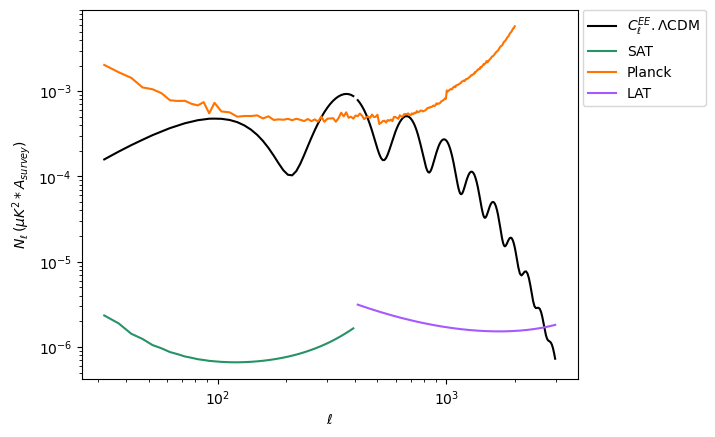

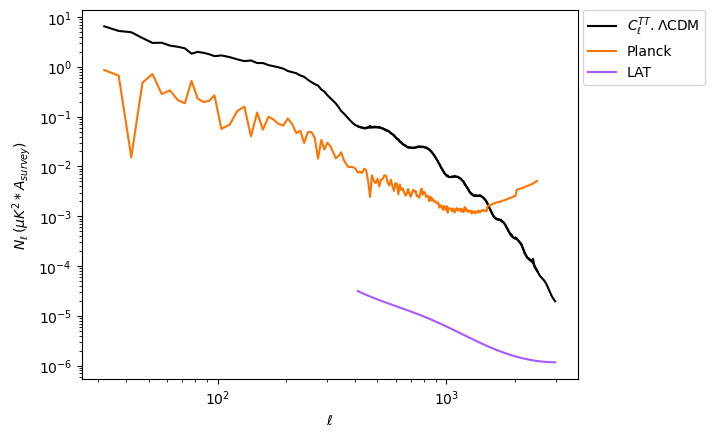

In [60]:
cmb_theo_lcdm = make_theory_from_case(None, theta_full['ad']['theta0'], {})

req_spec = make_req_spec(['SAT','LAT'])
setup = make_setup( yrs = 5,
                    f_mode = 0,
                    sens_mode = 1,
                  )
so_mock_y5 = build_full_lik_data(req_spec, setup, full_noise_dict, cmb_theo_lcdm)

so_lik_unif = make_unified_noise(so_mock_y5 ,ELL_SCHEME, add_lite = True,lite_data = lite_data)

dict_temp = so_lik_unif['data']

#plotting the c_ell
plt.plot(so_lik_unif['data']['SAT']['ell'],so_lik_unif['data']['SAT']['c_ell'], label = r'$C_\ell^{EE}. \Lambda$CDM',color = 'black')
plt.plot(so_lik_unif['data']['LAT_pol']['ell'],so_lik_unif['data']['LAT_pol']['c_ell'],  color = 'black')

from colors import assign_colors
exps = ['SAT','PK_lite_pol','LAT_pol']
colors = assign_colors(exps)
labels = ['SAT','Planck','LAT']
for i,exp in enumerate(exps):
    plt.plot(dict_temp[exp]['ell'],np.abs(dict_temp[exp]['n_ell']), label = labels[i], color = colors[exp])


plt.ylabel(r'$N_\ell \, (\mu K^2 * A_{survey})$')
plt.xlabel(r'$\ell$')
plt.loglog()
#plt.title('Unified Noise Curves')
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.savefig('images/thes_final/misc/ee_noise_unif.pdf', dpi=300, bbox_inches='tight')
plt.show()

#plotting the c_ell
plt.plot(so_lik_unif['data']['PK_lite']['ell'],so_lik_unif['data']['PK_lite']['c_ell'], label = r'$C_\ell^{TT}. \Lambda$CDM',color = 'black')
plt.plot(so_lik_unif['data']['LAT']['ell'],so_lik_unif['data']['LAT']['c_ell'],  color = 'black')

from colors import assign_colors
exps = ['PK_lite','LAT']
colors = assign_colors(exps)
labels = ['Planck','LAT']
for i,exp in enumerate(exps):
    plt.plot(dict_temp[exp]['ell'],np.abs(dict_temp[exp]['n_ell']), label = labels[i], color = colors[exp])


plt.ylabel(r'$N_\ell \, (\mu K^2 * A_{survey})$')
plt.xlabel(r'$\ell$')
plt.loglog()
#plt.title('Unified Noise Curves')
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
plt.savefig('images/thes_final/misc/tt_noise_unif.pdf', dpi=300, bbox_inches='tight')


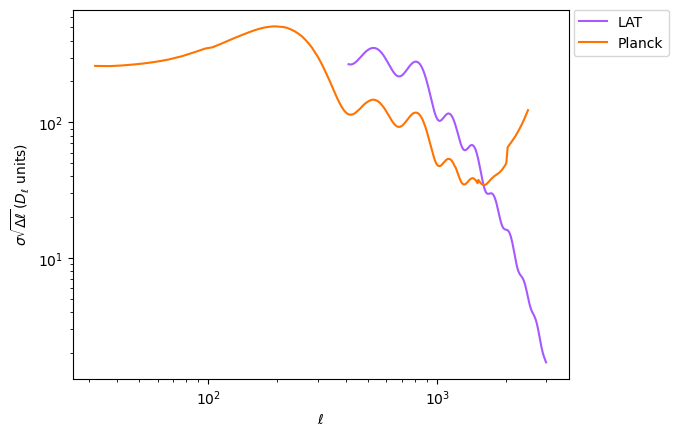

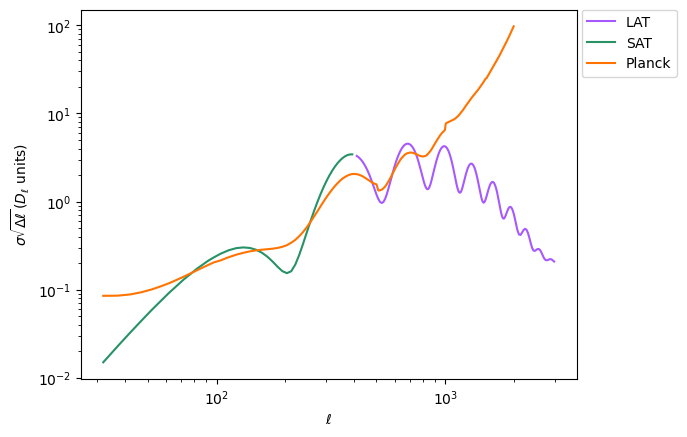

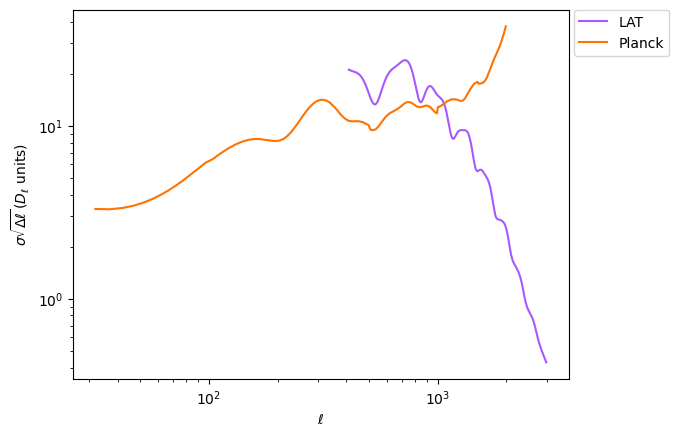

In [59]:
def _knox_prefactor(ell, fsky, cross=False):
    """sqrt(dell)*sigma = (signal) * sqrt(k / [(2l+1) fsky]), k=2 auto, k=1 cross."""
    k = 1.0 if cross else 2.0
    return np.sqrt(k / ((2.0 * ell + 1.0) * fsky))

from colors import assign_colors, EXP_TO_FAMILY, FAMILY_PALETTES

DISPLAY_NAMES = {
    'LAT':            'LAT',
    'LAT_pol':        'LAT',
    'LAT_cross':      'LAT',
    'SAT':            'SAT',
    'PK':             'Planck',
    'PK_pol':         'Planck',
    'PK_cross':       'Planck',
    'PK_lite':        'Planck',
    'PK_lite_pol':    'Planck',
    'PK_lite_cross':  'Planck',
}


def plot_cov(exp_temp_arr, cell_type, so_lik_unif,
             pref=True, include_cv=False):
    """
    include_cv=False: solid total sigma*sqrt(dell) per experiment.
    include_cv=True : also plot CV-only (dashed) and noise-only (dotted) per
                      experiment in shades from the same family palette.
                      For TE, only the dashed pure-CV-limit line is added.
    """
    is_cross = (cell_type == 'TE')
    colors   = assign_colors(exp_temp_arr)

    def _shades_for(exp):
        family  = EXP_TO_FAMILY[exp]
        palette = FAMILY_PALETTES[family]
        solid   = colors[exp]
        solid_idx = palette.index(solid) if solid in palette else 0
        dashed_idx = (solid_idx + 1) % len(palette)
        dotted_idx = (solid_idx + 2) % len(palette)
        return palette[dashed_idx], palette[dotted_idx]

    for exp in exp_temp_arr:
        d     = so_lik_unif['data'][exp]
        meta  = so_lik_unif['metadata'][exp]
        ell   = d['ell']
        dell  = d['dell']
        c_ell = d['c_ell']
        n_ell = d['n_ell']
        fsky  = meta['fsky']
        color = colors[exp]

        dl_fac = ell * (ell + 1.0) / (2.0 * np.pi) if pref else 1.0

        err_total = np.sqrt(d['cov'] * dell) * dl_fac
        plt.plot(ell, err_total, label=DISPLAY_NAMES.get(exp, exp),
                 color=color, linestyle='-')

        if not include_cv:
            continue

        dashed_color, dotted_color = _shades_for(exp)
        k_pref = _knox_prefactor(ell, fsky, cross=is_cross)

        if not is_cross:
            cv_err    = np.abs(c_ell) * k_pref * dl_fac
            noise_err = np.abs(n_ell) * k_pref * dl_fac
            plt.plot(ell, cv_err,    color=dashed_color, linestyle='--')
            plt.plot(ell, noise_err, color=dotted_color, linestyle=':')
        else:
            auto_lookup = {
                'LAT_cross':     ('LAT',     'LAT_pol'),
                'PK_cross':      ('PK',      'PK_pol'),
                'PK_lite_cross': ('PK_lite', 'PK_lite_pol'),
            }
            if exp not in auto_lookup:
                continue
            tt_key, ee_key = auto_lookup[exp]
            if tt_key not in so_lik_unif['data'] or ee_key not in so_lik_unif['data']:
                continue
            c_tt = so_lik_unif['data'][tt_key]['c_ell']
            c_ee = so_lik_unif['data'][ee_key]['c_ell']
            # Truncate the autos to the TE length so all three line up.
            n = len(ell)
            c_tt = c_tt[:n]
            c_ee = c_ee[:n]
            cv_err = np.sqrt(c_ell**2 + c_tt * c_ee) * k_pref * dl_fac
            plt.plot(ell, cv_err, color=dashed_color, linestyle='--')

    if include_cv:
        plt.plot([], [], color='black', linestyle='--',
                 label=r'Cosmic Variance')
        if not is_cross:
            plt.plot([], [], color='black', linestyle=':',
                     label='Noise Contribution')

    ylabel = (r'$\sigma \sqrt{\Delta \ell} \, (D_\ell\ \mathrm{units})$' if pref
              else r'$\sigma \sqrt{\Delta \ell} \, (C_\ell\ \mathrm{units})$')
    plt.ylabel(ylabel)
    plt.xlabel(r'$\ell$')
    plt.loglog()
    plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
    suffix = '_cv' if include_cv else ''
    plt.savefig(f'images/thes_final/misc/cov_diag_{cell_type}{suffix}.pdf',
                dpi=300, bbox_inches='tight')
    plt.show()


# ── call sites ─────────────────────────────────────────────────────────────
WITH_PK_LITE = True
include_cv   = False

if WITH_PK_LITE:
    plot_cov(['LAT',       'PK_lite'],               'TT', so_lik_unif, include_cv=include_cv)
    plot_cov(['LAT_pol',   'SAT', 'PK_lite_pol'],    'EE', so_lik_unif, include_cv=include_cv)
    plot_cov(['LAT_cross', 'PK_lite_cross'],         'TE', so_lik_unif, include_cv=include_cv)
else:
    plot_cov(['LAT'],                                'TT', so_lik_unif, include_cv=include_cv)
    plot_cov(['LAT_pol',   'SAT'],                   'EE', so_lik_unif, include_cv=include_cv)
    plot_cov(['LAT_cross'],                          'TE', so_lik_unif, include_cv=include_cv)

things that I can (and eventually will) import:
**full_noise_dict**; but for now, I will make it above


In [9]:
def make_one_fisher(iso_type, corr_type , theta_full, full_noise_dict, ell_scheme, req_spec, setup, lite_data, param_list,
                    scaled10_params,
                    add_lite = True,
                    lmax_theo = 4000,
                    compute_cls = compute_cls,
                    steps_abs = {
                                "omega_b": 2.5e-5,
                                "omega_cdm": 1.5e-4,
                                "h": 6.0e-4,
                                "tau_reio": 6.0e-5,
                            },
                    steps_scaled10 = {
                                "P_RR_1": 0.01,
                                "P_RR_2": 0.01,
                                "P_II_1": 0.05,
                                "P_II_2": 0.05,
                            },
                    use_pinv = False,
                    ):

    #getting the theory dictionary:
    theta0 = theta_full[corr_type]['theta0']
    corr_dict = theta_full[corr_type]['corr']
    cmb_theo_dict = make_theory_from_case(iso_type,theta0,corr_dict, lmax_theo, compute_cls = compute_cls)

    if req_spec:
        lik_from_nz = build_full_lik_data(req_spec, setup, full_noise_dict, cmb_theo_dict)

        lik_unif = make_unified_noise(lik_from_nz ,ell_scheme, add_lite = add_lite,lite_data = lite_data)
    else:
        out_lite = {
            'metadata': {},
            'data':{},
        }
        lik_unif =  add_lite_to_out(out_lite,lite_data)

    lik_best = make_best_per_bin(lik_unif, ell_scheme)

    fisher = fisher_forecast_ttteee(
    theta0 = theta0,
    param_list = param_list ,
    so_lik_best = lik_best,
    compute_cls = compute_cls,
    steps = {**steps_abs, **steps_scaled10},
    scaled_params = scaled10_params,
    ell_max = lmax_theo,
    use_pinv = use_pinv,
    )

    return fisher
    

/tmp/ipykernel_2033228/348092344.py:4: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


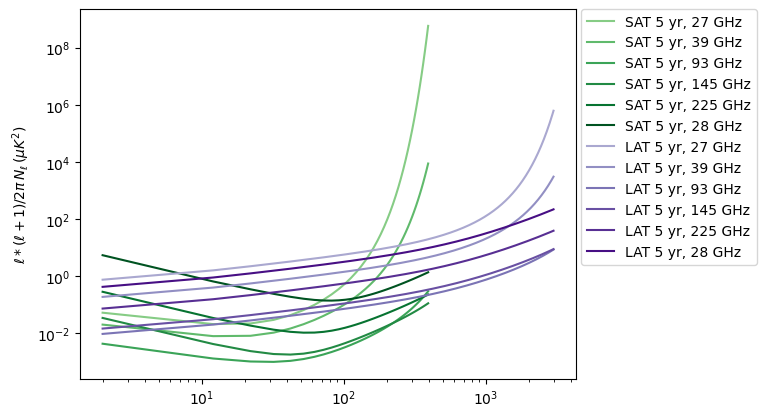

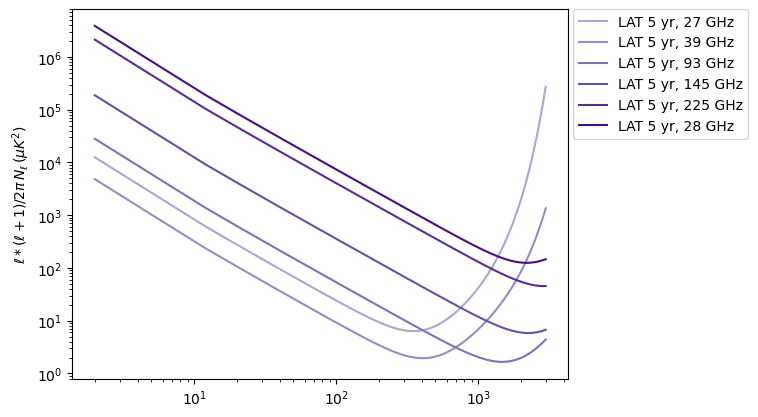

In [21]:
### ---------MANY-NOISE FIG BELOW!!!-------------------------------


'''import matplotlib.cm as cm

def get_colors(n, cmap_name):
    cmap = cm.get_cmap(cmap_name)
    return [cmap(x) for x in np.linspace(0.45, 0.95, max(n, 1))]


color_families = {
    #'PK':      'Blues',
    'SAT':     'Greens',
    'LAT_pol': 'Purples',
}

plot_groups = {
    #'PK':      ('PK_pol',    None,                    'PK'),
    'SAT':     ('SAT',       'SAT_y5_sm1fm0',         'SAT 5 yr'),
    'LAT_pol': ('LAT_pol',   'LAT_pol_y5_sm1',        'LAT 5 yr'),
}

for family, (top_key, sub_key, label_prefix) in plot_groups.items():
    dict_temp = full_noise_dict[top_key] if sub_key is None else full_noise_dict[top_key][sub_key]
    nz_dict   = dict_temp['nz_dict']
    ell_plot  = dict_temp['ell_nz']
    colors    = get_colors(len(nz_dict), color_families[family])




    for (key, spect), color in zip(nz_dict.items(), colors):
        key_fig = key.replace("f", "")
        if "0" in key_fig:
            key_fig = key_fig.replace("0", "")
        key_fig+= ' GHz'
        
        pref = ell_plot*(ell_plot+1)/2/np.pi
        plt.plot(ell_plot, pref * spect, color=color, label=f'{label_prefix}, {key_fig}')

#plt.title('EE noise')
plt.ylabel(r'$\ell*(\ell+1)/2\pi \, N_\ell \, (\mu K^2)$')
plt.loglog()
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
#plt.savefig('images/ee_noise.png', dpi=300, bbox_inches='tight')
plt.show()

color_families = {
    #'PK':  'Blues',
    'LAT': 'Purples',
}

plot_groups = {
    #'PK':  ('PK',  None,          'PK'),
    'LAT': ('LAT', 'LAT_y5_sm1',  'LAT 5 yr'),
}

for family, (top_key, sub_key, label_prefix) in plot_groups.items():
    dict_temp = full_noise_dict[top_key] if sub_key is None else full_noise_dict[top_key][sub_key]
    nz_dict   = dict_temp['nz_dict']
    ell_plot  = dict_temp['ell_nz']
    colors    = get_colors(len(nz_dict), color_families[family])


    for (key, spect), color in zip(nz_dict.items(), colors):
        key_fig = key.replace("f", "")
        if "0" in key_fig:
            key_fig = key_fig.replace("0", "")
        key_fig+= ' GHz'

        pref = ell_plot*(ell_plot+1)/2/np.pi
        plt.plot(ell_plot, pref * spect, color=color, label=f'{label_prefix}, {key_fig}')

#plt.title('TT noise')
plt.ylabel(r'$\ell*(\ell+1)/2\pi \, N_\ell \, (\mu K^2)$')
plt.loglog()
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
#plt.savefig('images/tt_noise.png', dpi=300, bbox_inches='tight')
plt.show()

In [10]:
### these are the settings without varying the correlation parameter;
#in all honesty, I don't think I'm going to have time 
ELL_SCHEME = extract_ell_scheme(lite_data)
ISO_ARR = ['cdi','nid','niv',None]
REQ_SPEC_SO = make_req_spec(['SAT','LAT'])
YRS_ARR = [1,5,10]
STEPS_ABS = {
    "omega_b": 2.5e-5,
    "omega_cdm": 1.5e-4,
    "h": 6.0e-4,
    "tau_reio": 6.0e-5,
}
param_list = [
    "omega_b", "omega_cdm", "h", "tau_reio",
    "P_RR_1", "P_RR_2", "P_II_1", "P_II_2"
]
scaled10_params = {"P_RR_1", "P_RR_2", "P_II_1", "P_II_2"}

steps_scaled10 = {
    "P_RR_1": 0.01,
    "P_RR_2": 0.01,
    "P_II_1": 0.05,
    "P_II_2": 0.05,
}

In [ ]:
#For every single thing, I need to plot them all and save the figures? Or what would be a helpful visualization?

In [83]:
fisher_5yr = deepcopy(ucor_fisher_so['cdi']['5yr'])

,Fiducial,sigma,S/N
omega_b,0.02237,0.000067,331.945548
omega_cdm,0.11933,0.000727,164.185749
h,0.67660,0.002961,228.498464
tau_reio,0.05610,0.010001,5.609435
P_RR_1,23.00000,0.462830,49.694260
P_RR_2,23.00000,0.437435,52.579279
P_II_1,23.00000,2.310900,9.952833
P_II_2,23.00000,2.517641,9.135535


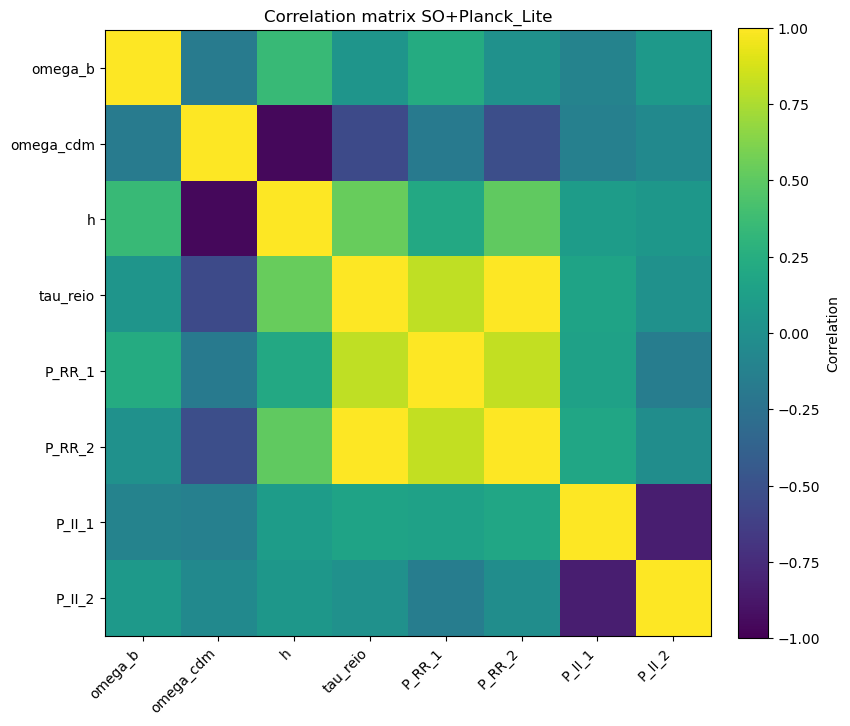

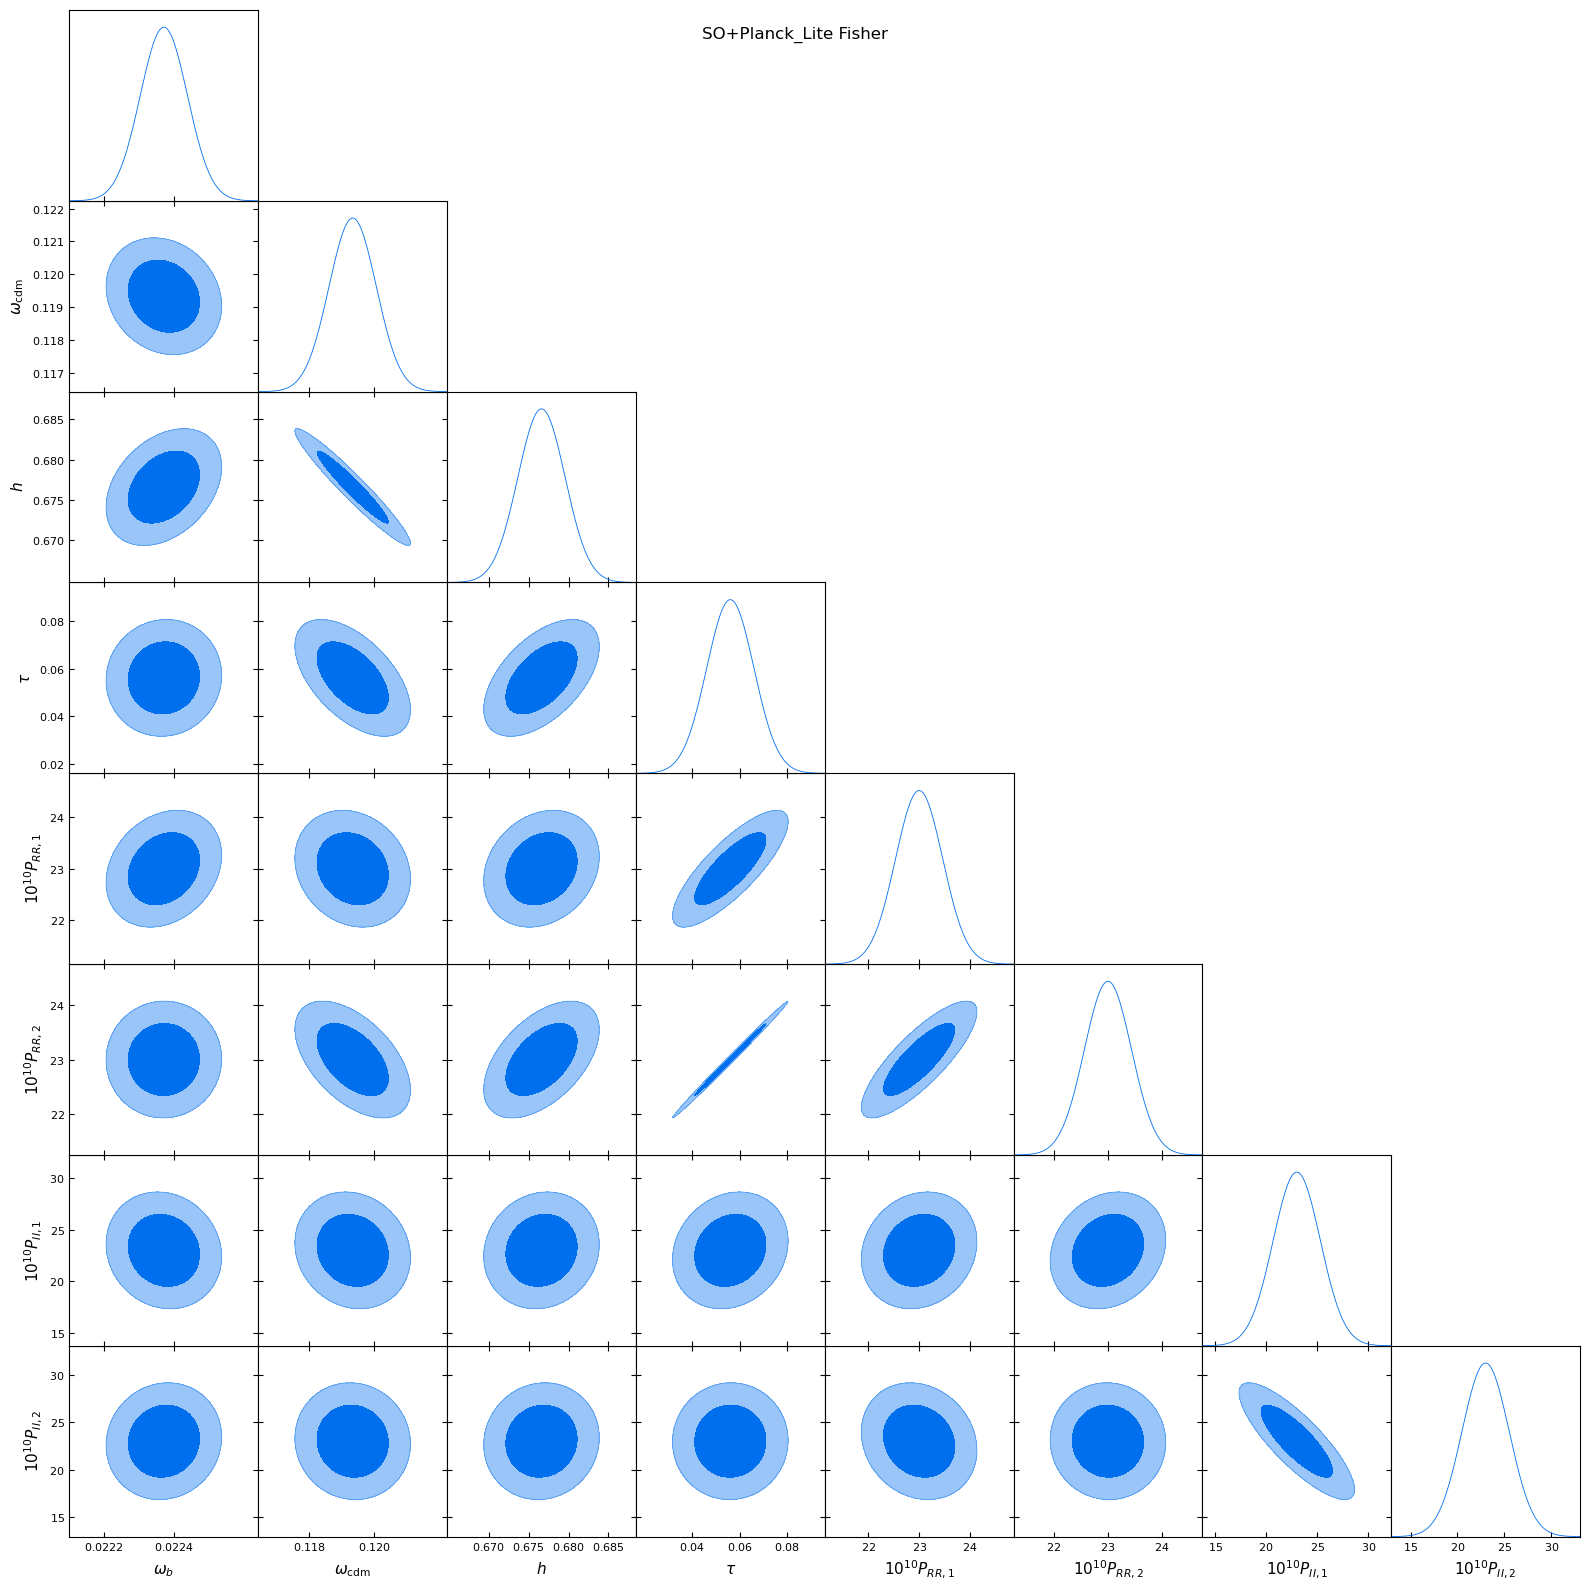

In [84]:
yr_string = '5yr'
iso_type = 'cdi'
plot_save_suite(fisher_5yr,
                'SO+Planck Lite',
               theta_full['ucor']['theta0'],
               scaled_params = SCALED10_PARAMS,
               save_dir = 'images/srths/{}/{}/{}'.format(corr_type,iso_type,yr_string))



### loading the data from the runner block:

In [47]:
with open('saved_fishers/so_fisher_all.pkl', 'rb') as f:
    so_fisher_all = pickle.load(f)

ok, awesome!!! now I have all the data. time to build the plotter for the results.

In [82]:
print((so_fisher_all['ucor']['SO']['cdi']['10yr'].sigma-so_fisher_all['ucor']['PK_Lite']['cdi']['10yr'].sigma)/so_fisher_all['ucor']['PK_Lite']['cdi']['10yr'].sigma)

[-0.5195297  -0.50540403 -0.54760551 -0.65623942 -0.63362079 -0.66686758
  0.34616956  0.16309302]


In [150]:
def print_keys(data, indent=0):
    for key, value in data.items():
        # Print the key with indentation for visual hierarchy
        print("  " * indent + str(key))
        
        # If the value is a nested dictionary, recurse
        if isinstance(value, dict):
            print_keys(value, indent + 1)
print_keys(muci)

acor
  LB
    cdi
      10yr
    nid
      10yr
    niv
      10yr
    None
      10yr
pcor
  LB
    cdi
      10yr
    nid
      10yr
    niv
      10yr
    None
      10yr
ucor
  LB
    cdi
      10yr
    nid
      10yr
    niv
      10yr
    None
      10yr


In [72]:
# ── setup ──────────────────────────────────────────────────────────────────
corr_plot = ['pcor', 'ucor', 'acor']
iso_plot  = ['cdi',  'nid',  'niv']

param_list      = ["omega_b", "omega_cdm", "h", "tau_reio",
                   "P_RR_1", "P_RR_2", "P_II_1", "P_II_2"]
scaled10_params = {"P_RR_1", "P_RR_2", "P_II_1", "P_II_2"}
regular_params  = [p for p in param_list if p not in scaled10_params]
scaled_params   = [p for p in param_list if p in     scaled10_params]

LATEX = {
    "omega_b":   r"\omega_b",
    "omega_cdm": r"\omega_{\rm cdm}",
    "h":         r"h",
    "tau_reio":  r"\tau",
    "P_RR_1":    r"10^{10}P_{RR,1}",
    "P_RR_2":    r"10^{10}P_{RR,2}",
    "P_II_1":    r"10^{10}P_{II,1}",
    "P_II_2":    r"10^{10}P_{II,2}",
}


# ── helpers ────────────────────────────────────────────────────────────────
def _centers_for(theta0, scaled_set, subset):
    return np.array(
        [1e10 * theta0[p] if p in scaled_set else theta0[p] for p in subset],
        dtype=float,
    )


def _gaussian_sub(fisher, theta0, scaled_set, subset, name):
    idx = [fisher.param_list.index(p) for p in subset]
    cov_sub = fisher.Cov_params[np.ix_(idx, idx)]
    centers = _centers_for(theta0, scaled_set, subset)
    labels  = [LATEX.get(p, p) for p in subset]
    return GaussianND(centers, cov_sub,
                      names=subset, labels=labels, label=name)


def _colors_for(fishers_named):
    """
    Map each named Fisher to a family color. Planck -> PK_lite palette,
    SO-anything -> LAT palette. Multiple SO entries cycle through LAT shades.
    """
    lat_palette = FAMILY_PALETTES['LAT']
    pk_palette  = FAMILY_PALETTES['PK_lite']
    lat_idx = 0
    pk_idx  = 0
    out = []
    for _, name in fishers_named:
        if name.startswith('Planck'):
            out.append(pk_palette[pk_idx % len(pk_palette)])
            pk_idx += 1
        else:  # 'SO ...'
            out.append(lat_palette[lat_idx % len(lat_palette)])
            lat_idx += 1
    return out


def triangle_overlay(fishers_named, theta0, scaled_set, subset, save_path):
    gaussians = [_gaussian_sub(f, theta0, scaled_set, subset, name)
                 for f, name in fishers_named]
    colors = _colors_for(fishers_named)

    g = plots.get_subplot_plotter()
    g.settings.axes_fontsize   = 16
    g.settings.axes_labelsize  = 20
    g.settings.legend_fontsize = 18
    g.settings.lab_fontsize    = 20

    g.triangle_plot(gaussians, subset, filled=True,
                    legend_labels=[name for _, name in fishers_named],
                    contour_colors=colors)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight')
    return g


# ── main loop ──────────────────────────────────────────────────────────────
def plot_save_suite_v2(result_dict, theta_full, corr_plot, iso_plot,
                       base_dir='images/srths', quiet=False):
    for corr in corr_plot:
        theta0 = theta_full[corr]['theta0']
        for iso in iso_plot:
            pk_fish = result_dict[corr]['PK_Lite'][iso]['5yr']
            so_5yr  = result_dict[corr]['SO'     ][iso]['5yr']
            so_1yr  = result_dict[corr]['SO'     ][iso]['1yr']
            so_10yr = result_dict[corr]['SO'     ][iso]['10yr']

            # Panel A: Planck vs SO-5yr
            dir_5yr = f"{base_dir}/{corr}/{iso}/5yr"
            os.makedirs(dir_5yr, exist_ok=True)

            triangle_overlay(
                [(pk_fish, 'Planck'), (so_5yr, 'SO 5yr')],
                theta0, set(), regular_params,
                save_path=f"{dir_5yr}/triangle_regular.pdf",
            )
            if not quiet:
                plt.show()
            else:
                plt.close('all')

            triangle_overlay(
                [(pk_fish, 'Planck'), (so_5yr, 'SO 5yr')],
                theta0, scaled10_params, scaled_params,
                save_path=f"{dir_5yr}/triangle_scaled.pdf",
            )
            if not quiet:
                plt.show()
            else:
                plt.close('all')

            with plt.rc_context({'font.size': 14,
                                 'axes.titlesize': 16,
                                 'axes.labelsize': 16,
                                 'xtick.labelsize': 12,
                                 'ytick.labelsize': 12}):
                pk_fish.plot_correlation(
                    exp_name=f"Planck ({corr}/{iso})",
                    save_path=f"{dir_5yr}/corr_PK.pdf",
                )
                if not quiet:
                    plt.show()
                else:
                    plt.close('all')
                so_5yr.plot_correlation(
                    exp_name=f"SO 5yr ({corr}/{iso})",
                    save_path=f"{dir_5yr}/corr_SO5yr.pdf",
                )
                if not quiet:
                    plt.show()
                else:
                    plt.close('all')

            df_pk = pk_fish.save_summary_table(
                theta0=theta0, scaled_params=scaled10_params,
                exp_name=f"PK_{corr}_{iso}",
                save_path=f"{dir_5yr}/table_PK.pdf",
            )
            df_so = so_5yr.save_summary_table(
                theta0=theta0, scaled_params=scaled10_params,
                exp_name=f"SO5yr_{corr}_{iso}",
                save_path=f"{dir_5yr}/table_SO5yr.pdf",
            )
            if not quiet:
                display(df_pk)
                display(df_so)

            # Panel B: Planck + SO-1yr + SO-10yr
            dir_3way = f"{base_dir}/{corr}/{iso}/1yr_10yr"
            os.makedirs(dir_3way, exist_ok=True)

            triangle_overlay(
                [(pk_fish, 'Planck'),
                 (so_1yr,  'SO 1yr'),
                 (so_10yr, 'SO 10yr')],
                theta0, set(), regular_params,
                save_path=f"{dir_3way}/triangle_regular.pdf",
            )
            if not quiet:
                plt.show()
            else:
                plt.close('all')

            triangle_overlay(
                [(pk_fish, 'Planck'),
                 (so_1yr,  'SO 1yr'),
                 (so_10yr, 'SO 10yr')],
                theta0, scaled10_params, scaled_params,
                save_path=f"{dir_3way}/triangle_scaled.pdf",
            )
            if not quiet:
                plt.show()
            else:
                plt.close('all')


#plot_save_suite_v2(so_fisher_all, theta_full,
                   #corr_plot=corr_plot, iso_plot=iso_plot, quiet = True)

### the sigma progression plot:

## ADDING LITEBIRD:

- I will take the TT datapoints from the plik-lite-py dataset (so i didn't do all that for nothing)
- I will generate two LiteBIRD datapoints (EE = C_ell + Noise, )
- TE covariance and datapoints stay the same, so I just have to be careful with that ell-grid I generate. Shouldn't be too hard.

Plots for tomorrow:
    - redo all the plots you wanted to show Jo (pray to God they look the same as what you showed her)
    - make the isocurvature plots ()
    - 
    

In [144]:
# ---- frequencies -----------------------------------------------------------
LB_FREQ = [40, 50, 60, 68, 78, 89, 100, 119, 140, 166, 195, 235, 280, 337, 402]
frequencies['LB'] = ["{:03d}".format(f) for f in LB_FREQ]


# ---- sub-component table ---------------------------------------------------
# Per nominal frequency: list of (sigma_P [uK*arcmin], beam FWHM [arcmin]).
# Bands with two entries are dual-telescope; they get combined below.
LB_subcomponents = {
    40 : [(37.42, 70.5)],
    50 : [(33.46, 58.5)],
    60 : [(21.31, 51.1)],
    68 : [(19.91, 41.6), (31.77, 47.1)],
    78 : [(15.55, 36.9), (19.13, 43.8)],
    89 : [(12.28, 33.0), (28.77, 41.5)],
    100: [(10.34, 30.2), ( 8.48, 37.8)],
    119: [( 7.69, 26.3), ( 5.70, 33.6)],
    140: [( 7.25, 23.7), ( 6.38, 30.8)],
    166: [( 5.57, 28.9)],
    195: [( 7.05, 28.0), (10.50, 28.6)],
    235: [(10.79, 24.7)],
    280: [(13.80, 22.5)],
    337: [(21.95, 20.9)],
    402: [(47.45, 17.9)],
}


# ---- ell grid --------------------------------------------------------------
lmin_lb = 2
lmax_lb = 200
dell_lb = 10
ell_pk_lb = np.arange(lmin_lb, lmax_lb, dell_lb)


# ---- build eenz_LB ---------------------------------------------------------
# eenz_LB[i] is the (intra-band combined) N_ell^EE for frequencies['LB'][i].
eenz_LB = np.zeros((len(LB_FREQ), len(ell_pk_lb)))
for i, freq in enumerate(LB_FREQ):
    inv_N = np.zeros_like(ell_pk_lb, dtype=float)
    for (sigma_P_arcmin, fwhm_arcmin) in LB_subcomponents[freq]:
        sigma_pol_rad = np.deg2rad(sigma_P_arcmin / 60.0)
        beam_rad      = fwhm_arcmin / np.sqrt(8.0 * np.log(2.0)) / 60.0 * np.pi / 180.0
        N_comp        = (sigma_pol_rad**2 * 4 * np.pi
                         * np.exp(ell_pk_lb * (ell_pk_lb + 1) * beam_rad**2))
        inv_N += 1.0 / N_comp
    eenz_LB[i] = 1.0 / inv_N


# ---- drop into full_noise_dict --------------------------------------------
# Exactly the same six keys as full_noise_dict['PK_pol'] in your first message.
full_noise_dict['LB'] = {
    'lmax'   : lmax_lb,
    'dell'   : dell_lb,
    'fsky'   : 0.7,
    'cuts'   : [lmin_lb, lmax_lb],
    'nz_dict': make_nz_dict_from_array(eenz_LB, frequencies, 'LB'),
    'ell_nz' : ell_pk_lb,
}

In [100]:
LB_ELL_SCHEME = deepcopy(ELL_SCHEME)
for key in LB_ELL_SCHEME.keys():
    new_ell = np.insert(LB_ELL_SCHEME[key]['ell'],[0,0],[8.5,22.5])
    LB_ELL_SCHEME[key]['ell'] = new_ell
    new_dell = np.insert(LB_ELL_SCHEME[key]['dell'],[0,0],[14,14])
    LB_ELL_SCHEME[key]['dell'] = new_dell

In [108]:
theta0 = theta_full['ucor']['theta0']
corr_dict = theta_full['ucor']['corr']
cmb_theo_dict = make_theory_from_case('cdi',theta0,corr_dict, 3000, compute_cls = compute_cls)

req_spec_lb = make_req_spec(['LAT','LB'])
setup_lb =  make_setup(5, 0, 1)


In [120]:
lb_lik_from_nz = build_full_lik_data(req_spec_lb, setup_lb, full_noise_dict, cmb_theo_dict)

lb_lik_unif = make_unified_noise(lb_lik_from_nz ,LB_ELL_SCHEME, add_lite = True,lite_data = lite_data)

lb_best = make_best_per_bin(lb_lik_unif,LB_ELL_SCHEME,add_lite = True)

In [153]:
import matplotlib.cm as cm
import matplotlib.colors as mcolors

def _sample(cmap_name, positions):
    """Sample hex colors from a colormap at given [0,1] positions."""
    cmap = cm.get_cmap(cmap_name)
    return [mcolors.to_hex(cmap(p)) for p in positions]


# Default position for single-curve plots: first entry of each list.
FAMILY_PALETTES = {
    # summer: 0.0 teal-green → 1.0 yellow
    'SAT':     _sample('summer', [0.15, 0.45, 0.75, 0.95]),

    # cool: 0.0 cyan → 1.0 magenta
    # order: purple (default), magenta, blue, cyan
    'LAT':     _sample('cool',   [0.65, 0.95, 0.35, 0.05]),

    # autumn: 0.0 red → 1.0 yellow; trimmed before the yellow end
    # order: orange (default), red, deep red, burnt orange
    'PK_lite': _sample('autumn', [0.45, 0.0, 0.15, 0.3]),

    # LiteBIRD: hardcoded grey (default) + yellow
    'LB':      ['#ffcc00','#7f7f7f'],
}


EXP_TO_FAMILY = {
    'SAT':            'SAT',
    'LAT':            'LAT',
    'LAT_pol':        'LAT',
    'LAT_cross':      'LAT',
    'PK':             'PK_lite',
    'PK_pol':         'PK_lite',
    'PK_cross':       'PK_lite',
    'PK_lite':        'PK_lite',
    'PK_lite_pol':    'PK_lite',
    'PK_lite_cross':  'PK_lite',
    'LB':             'LB',
}


def get_color(exp_key, index=0):
    """
    Return a hex color for a given experiment.

    Parameters
    ----------
    exp_key : str
        Experiment key, e.g. 'SAT', 'LAT_pol', 'PK_lite_cross'.
    index : int, default 0
        Which color within the family palette. 0 is the family default.
        Wraps around if index exceeds palette length.
    """
    family = EXP_TO_FAMILY[exp_key]
    palette = FAMILY_PALETTES[family]
    return palette[index % len(palette)]


def assign_colors(exp_keys):
    """
    Given a list of experiments to plot, hand each a color, cycling within
    family so same-family curves stay distinct.

    The first occurrence of a family gets palette[0] (the default), the
    second gets palette[1], and so on.
    """
    family_counter = {}
    colors = {}
    for exp in exp_keys:
        family = EXP_TO_FAMILY[exp]
        idx = family_counter.get(family, 0)
        colors[exp] = get_color(exp, idx)
        family_counter[family] = idx + 1
    return colors

/tmp/ipykernel_2033228/1187536957.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap(cmap_name)


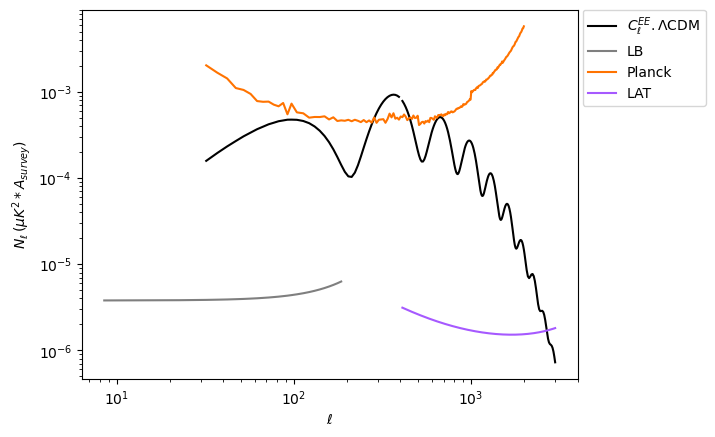

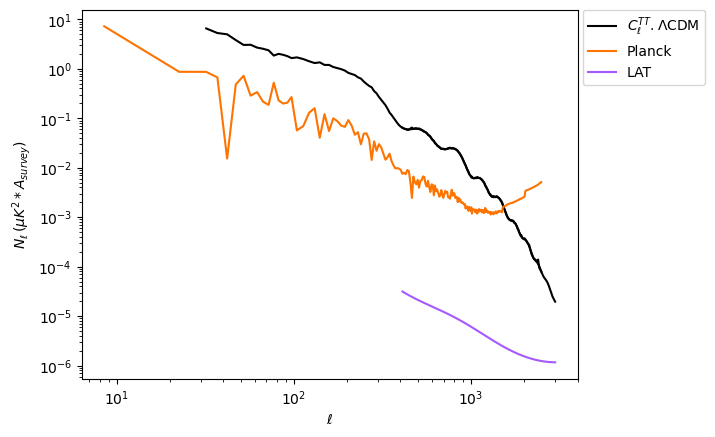

In [136]:
#plotting the c_ell
#from colors import assign_colors, EXP_TO_FAMILY, FAMILY_PALETTES
dict_temp = lb_lik_unif['data']

plt.plot(so_lik_unif['data']['SAT']['ell'],so_lik_unif['data']['SAT']['c_ell'], label = r'$C_\ell^{EE}. \Lambda$CDM',color = 'black')
plt.plot(so_lik_unif['data']['LAT_pol']['ell'],so_lik_unif['data']['LAT_pol']['c_ell'],  color = 'black')

exps = ['LB','PK_lite_pol','LAT_pol']
colors = assign_colors(exps)
labels = ['LB','Planck','LAT']
for i,exp in enumerate(exps):
    plt.plot(dict_temp[exp]['ell'],np.abs(dict_temp[exp]['n_ell']), label = labels[i], color = colors[exp])


plt.ylabel(r'$N_\ell \, (\mu K^2 * A_{survey})$')
plt.xlabel(r'$\ell$')
plt.loglog()
#plt.title('Unified Noise Curves')
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
#plt.savefig('images/thes_final/misc/ee_noise_unif.pdf', dpi=300, bbox_inches='tight')
plt.show()

#plotting the c_ell
plt.plot(so_lik_unif['data']['PK_lite']['ell'],so_lik_unif['data']['PK_lite']['c_ell'], label = r'$C_\ell^{TT}. \Lambda$CDM',color = 'black')
plt.plot(so_lik_unif['data']['LAT']['ell'],so_lik_unif['data']['LAT']['c_ell'],  color = 'black')

from colors import assign_colors
exps = ['PK_lite','LAT']
colors = assign_colors(exps)
labels = ['Planck','LAT']
for i,exp in enumerate(exps):
    plt.plot(dict_temp[exp]['ell'],np.abs(dict_temp[exp]['n_ell']), label = labels[i], color = colors[exp])


plt.ylabel(r'$N_\ell \, (\mu K^2 * A_{survey})$')
plt.xlabel(r'$\ell$')
plt.loglog()
#plt.title('Unified Noise Curves')
plt.legend(loc='upper left', bbox_to_anchor=(1.01, 1), borderaxespad=0)
#plt.savefig('images/thes_final/misc/tt_noise_unif.pdf', dpi=300, bbox_inches='tight')


In [126]:
fisher_lb = fisher_forecast_ttteee(
    theta0 = theta0,
    param_list = param_list,
    so_lik_best =   lb_best,
    compute_cls=   compute_cls,
    steps =   {**STEPS_ABS, **steps_scaled10}    ,
    scaled_params = scaled10_params,
    ell_max =       3000,
    use_pinv = False,
)

,Fiducial,sigma,S/N
omega_b,0.02237,0.000062,360.283286
omega_cdm,0.11933,0.000514,231.957765
h,0.67660,0.002189,309.146298
tau_reio,0.05610,0.009208,6.092382
P_RR_1,23.00000,0.440301,52.236969
P_RR_2,23.00000,0.405408,56.732918
P_II_1,15.00000,1.324076,11.328658
P_II_2,15.00000,1.752908,8.557207


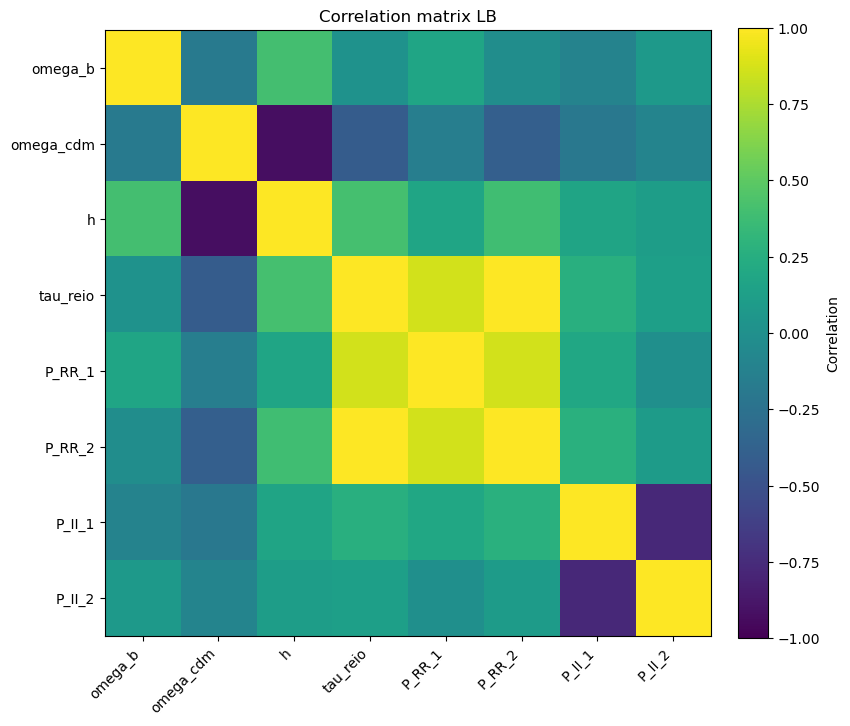

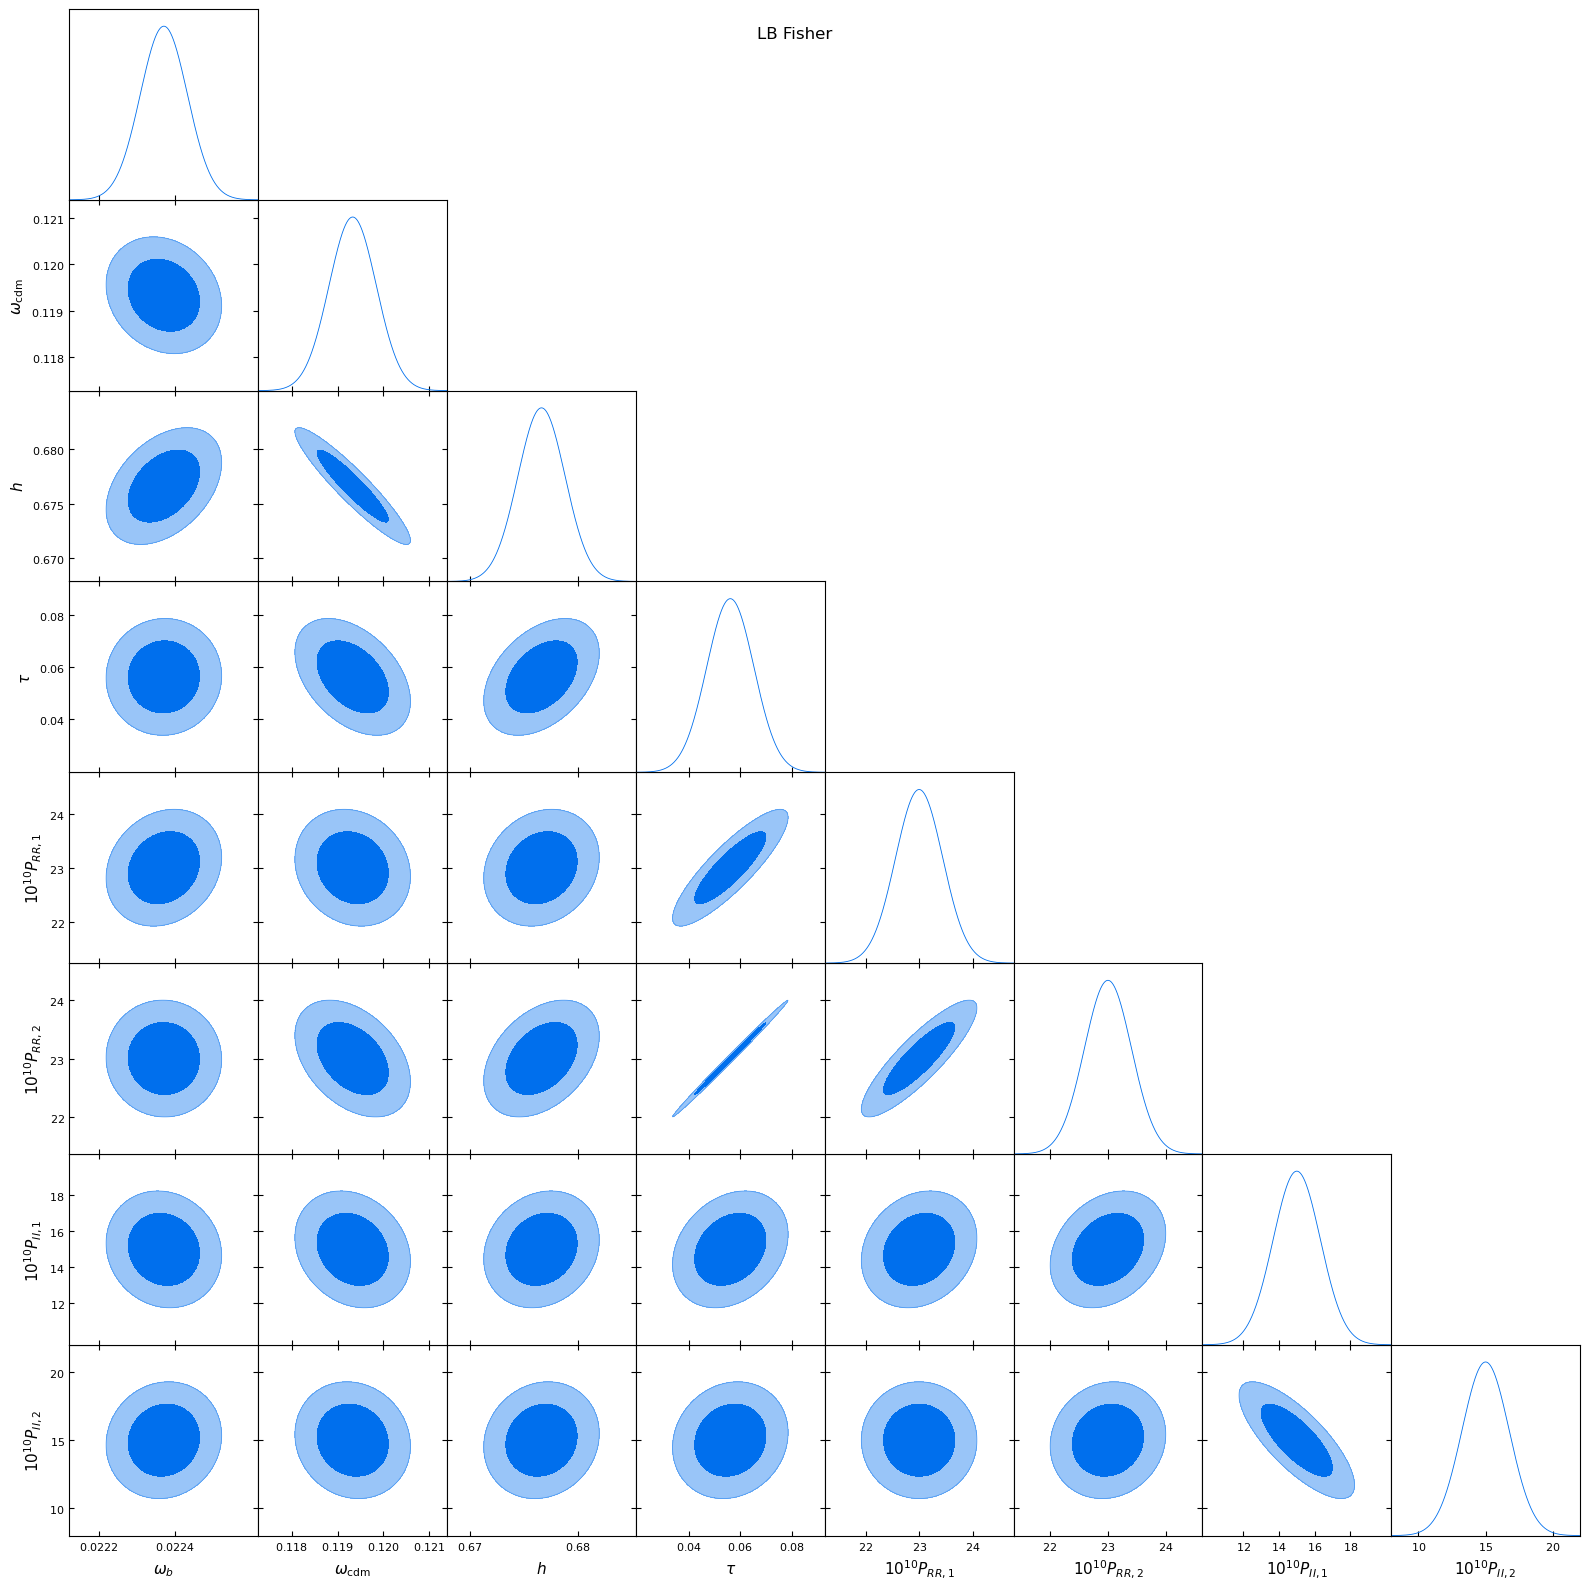

In [139]:
plot_save_suite(fisher_lb, 
                    'LB',
                    theta0,
                    scaled10_params,
                    "images/srths/misc",
                   )

In [142]:
### --- finally! building the LiteBIRD dict and then comparing three of them!!!

### these are the settings without varying the correlation parameter;
ISO_ARR = ['cdi','nid','niv',None]
YRS_ARR = [10]
STEPS_ABS = {
    "omega_b": 2.5e-5,
    "omega_cdm": 1.5e-4,
    "h": 6.0e-4,
    "tau_reio": 6.0e-5,
}
param_list = [
    "omega_b", "omega_cdm", "h", "tau_reio",
    "P_RR_1", "P_RR_2", "P_II_1", "P_II_2"
]
scaled10_params = {"P_RR_1", "P_RR_2", "P_II_1", "P_II_2"}

steps_scaled10 = {
    "P_RR_1": 0.01,
    "P_RR_2": 0.01,
    "P_II_1": 0.05,
    "P_II_2": 0.05,
}

In [145]:
corr_type = 'pcor'
litebird_pcor = {'LB':{},
                }



for i,iso_type in enumerate(ISO_ARR):
    litebird_pcor['LB'][iso_type] = {}
    for yr in YRS_ARR:
        
        setup_curr = make_setup( yrs = yr,
                        f_mode = 0,
                        sens_mode = 1,
                      )
        yr_string = str(yr) + 'yr'
        litebird_pcor['LB'][iso_type][yr_string] = make_one_fisher(iso_type, corr_type , theta_full, full_noise_dict,LB_ELL_SCHEME ,  req_spec_lb, 
                                                         setup_curr, 
                                                         lite_data, 
                                                         param_list,
                                                        scaled10_params,
                                                        steps_abs = STEPS_ABS,
                                                        steps_scaled10 = steps_scaled10,
                                                        use_pinv = False,
                                                                )



In [146]:
corr_type = 'ucor'
litebird_ucor = {'LB':{},
                }



for i,iso_type in enumerate(ISO_ARR):
    litebird_ucor['LB'][iso_type] = {}
    for yr in YRS_ARR:
        
        setup_curr = make_setup( yrs = yr,
                        f_mode = 0,
                        sens_mode = 1,
                      )
        yr_string = str(yr) + 'yr'
        litebird_ucor['LB'][iso_type][yr_string] = make_one_fisher(iso_type, corr_type , theta_full, full_noise_dict,LB_ELL_SCHEME ,  req_spec_lb, 
                                                         setup_curr, 
                                                         lite_data, 
                                                         param_list,
                                                        scaled10_params,
                                                        steps_abs = STEPS_ABS,
                                                        steps_scaled10 = steps_scaled10,
                                                        use_pinv = False,
                                                                )

corr_type = 'acor'
litebird_acor = {'LB':{},
                }



for i,iso_type in enumerate(ISO_ARR):
    litebird_acor['LB'][iso_type] = {}
    for yr in YRS_ARR:
        
        setup_curr = make_setup( yrs = yr,
                        f_mode = 0,
                        sens_mode = 1,
                      )
        yr_string = str(yr) + 'yr'
        litebird_acor['LB'][iso_type][yr_string] = make_one_fisher(iso_type, corr_type , theta_full, full_noise_dict,LB_ELL_SCHEME ,  req_spec_lb, 
                                                         setup_curr, 
                                                         lite_data, 
                                                         param_list,
                                                        scaled10_params,
                                                        steps_abs = STEPS_ABS,
                                                        steps_scaled10 = steps_scaled10,
                                                        use_pinv = False,
                                                                )

In [147]:
muci = {}
muci['acor'] = deepcopy(litebird_acor)
muci['pcor'] = deepcopy(litebird_pcor)
muci['ucor'] = deepcopy(litebird_ucor)

In [148]:
with open('saved_fishers/lb_fisher_10.pkl', 'wb') as f:
    pickle.dump(muci, f)

In [154]:
# assumed in scope: FAMILY_PALETTES, LATEX, regular_params,
# scaled_params, scaled10_params


def _centers_for(theta0, scaled_set, subset):
    return np.array(
        [1e10 * theta0[p] if p in scaled_set else theta0[p] for p in subset],
        dtype=float,
    )


def _gaussian_sub(fisher, theta0, scaled_set, subset, name):
    idx = [fisher.param_list.index(p) for p in subset]
    cov_sub = fisher.Cov_params[np.ix_(idx, idx)]
    centers = _centers_for(theta0, scaled_set, subset)
    labels  = [LATEX.get(p, p) for p in subset]
    return GaussianND(centers, cov_sub,
                      names=subset, labels=labels, label=name)


def _colors_for(fishers_named):
    """
    Map each named Fisher to a family color.
      'Planck ...'   -> PK_lite palette
      'LiteBIRD ...' -> LB palette
      anything else  -> LAT palette (SO)
    """
    lat_palette = FAMILY_PALETTES['LAT']
    pk_palette  = FAMILY_PALETTES['PK_lite']
    lb_palette  = FAMILY_PALETTES['LB']
    lat_idx = pk_idx = lb_idx = 0
    out = []
    for _, name in fishers_named:
        if name.startswith('Planck'):
            out.append(pk_palette[pk_idx % len(pk_palette)])
            pk_idx += 1
        elif name.startswith('LiteBIRD'):
            out.append(lb_palette[lb_idx % len(lb_palette)])
            lb_idx += 1
        else:  # 'SO ...'
            out.append(lat_palette[lat_idx % len(lat_palette)])
            lat_idx += 1
    return out


def triangle_overlay(fishers_named, theta0, scaled_set, subset, save_path):
    gaussians = [_gaussian_sub(f, theta0, scaled_set, subset, name)
                 for f, name in fishers_named]
    colors = _colors_for(fishers_named)
    g = plots.get_subplot_plotter()
    g.settings.axes_fontsize   = 16
    g.settings.axes_labelsize  = 20
    g.settings.legend_fontsize = 18
    g.settings.lab_fontsize    = 20
    g.triangle_plot(gaussians, subset, filled=True,
                    legend_labels=[name for _, name in fishers_named],
                    contour_colors=colors)
    os.makedirs(os.path.dirname(save_path), exist_ok=True)
    plt.savefig(save_path, bbox_inches='tight')
    return g


def _show_or_close(quiet):
    if not quiet:
        plt.show()
    else:
        plt.close('all')


# ── main loop ──────────────────────────────────────────────────────────────
def plot_save_suite_v3(so_fisher_all, muci, theta_full, corr_plot, iso_plot,
                       base_dir='images/srths', quiet=False):
    for corr in corr_plot:
        theta0 = theta_full[corr]['theta0']
        for iso in iso_plot:
            pk_10yr = so_fisher_all[corr]['PK_Lite'][iso]['10yr']
            so_10yr = so_fisher_all[corr]['SO'     ][iso]['10yr']
            lb_10yr = muci[corr]['LB'][iso]['10yr']

            # ── LiteBIRD-10yr + Planck-10yr + SO-10yr overlay ────────────
            dir_lb = f"{base_dir}/lb_10yr"
            os.makedirs(dir_lb, exist_ok=True)
            triangle_overlay(
                 [(pk_10yr, 'Planck 10yr'),
                 (so_10yr, 'SO 10yr'),
                (lb_10yr, 'LiteBIRD 10yr')],
                theta0, set(), regular_params,
                save_path=f"{dir_lb}/triangle_regular_lb_{corr}_{iso}.pdf",
            )
            _show_or_close(quiet)
            triangle_overlay(
                [(pk_10yr, 'Planck 10yr'),
                 (so_10yr, 'SO 10yr'),
                (lb_10yr, 'LiteBIRD 10yr')],
                theta0, scaled10_params, scaled_params,
                save_path=f"{dir_lb}/triangle_scaled_lb_{corr}_{iso}.pdf",
            )
            _show_or_close(quiet)


plot_save_suite_v3(so_fisher_all, muci, theta_full,
                    corr_plot=corr_plot, iso_plot=iso_plot, quiet=True)